# H4: Experience and Normalization

**Hypothesis**: Greater prior interview experience will be associated with higher normalization of dishonest behavior. Repeated exposure to competitive hiring gradually erodes categorical ethical commitments, replacing them with contextual or instrumental reasoning.

**Two competing theoretical mechanisms:**
- **Moral disengagement** (Bandura, 1999) — experience shifts *acceptability ratings* (Q3)
- **Social learning** — experience shifts *peer cheating estimates* (Q2)

**Relevant Survey Items:**
| Variable | Column | Question |
|---|---|---|
| `q19_num_interviews` | Question 19 | Number of professional interviews completed |
| `q13a_willingness_high` | Question 13a | Willingness to cheat under high peer cheating conditions |
| `q14a_willingness_no` | Question 14a | Willingness to cheat under no peer cheating conditions |
| `q2_pct_cheated` | Question 2_1 | Estimated % of peers who have cheated |
| `q3_*` | Question 3_1–3_6 | Acceptability ratings for 6 cheating behaviors |
| `q16_field` | Question 16 | Field of study |
| `q17_industry` | Question 17 | Current/desired industry |
| `q15_year` | Question 15 | Academic year / career stage |
| `q23_detect_n` | Optional Q3 | Detection confidence (for Generally Willing analysis) |
| `q24_enforce_n` | Optional Q4 | Enforcement confidence (for Generally Willing analysis) |

---

## 1. Setup and Data Loading

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi'       : 150,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})
HUMAN_COLOR   = '#2563EB'
AGENT_COLOR   = '#DC2626'
NEUTRAL_COLOR = '#6B7280'
BAND_COLORS   = ['#BFD7FF', '#6AA3F8', '#2563EB', '#0D3A8A']  # light→dark blue per experience band

print('Libraries loaded.')

Libraries loaded.


In [28]:
# ── Load data ──────────────────────────────────────────────────────────────────
# Row 0  = question text (long-form)
# Row 1  = Qualtrics import IDs  → skip
# Rows 2+ = actual responses
#raw = pd.read_excel('New Microsoft Excel Worksheet.xlsx', header=0)
raw = pd.read_excel("cleaned.xlsx", header=0)

# Human responses start at row index 2 (0-indexed in the raw frame)
df = raw.iloc[1:].copy().reset_index(drop=True)

# Rename columns to short, meaningful labels using the survey map below
col_map = {
    'Consent Page'            : 'consent',
    'Question 1_1'            : 'q1_smartphone',
    'Question 1_2'            : 'q1_music',
    'Question 1_3'            : 'q1_coffee',
    'Question 1_4'            : 'q1_skydive',
    'Question 1_5'            : 'q1_helicopter',
    'Question 1_6'            : 'q1_pay_interview',
    'Question 1_7'            : 'q1_gym',
    'Question 1_8'            : 'q1_cheat_partner',
    'Question 1_9'            : 'q1_exam_cheat',
    'Question 1_10'           : 'q1_ai_interview_answers',
    'Question 1_11'           : 'q1_ai_practice',
    'Question 1_12'           : 'q1_essay_ghost',
    'Question 1_13'           : 'q1_hidden_assist',
    'Question 1_14'           : 'q1_perform_music',
    'Question 2_1'            : 'q2_pct_cheated',
    'Question 3_1'            : 'q3_ai_during',
    'Question 3_2'            : 'q3_search_engine',
    'Question 3_3'            : 'q3_questions_beforehand',
    'Question 3_4'            : 'q3_live_assist',
    'Question 3_5'            : 'q3_handwritten_notes',
    'Question 3_6'            : 'q3_ai_notes',
    'Question 4'              : 'q4_attention_color',
    'Question 5a_1'           : 'q5a_desperation',
    'Question 5a_2'           : 'q5a_competition',
    'Question 5a_3'           : 'q5a_confidence',
    'Question 5a_4'           : 'q5a_unfair_process',
    'Question 5a_5'           : 'q5a_online_risk',
    'Question 5a_6'           : 'q5a_cultural_norms',
    'Question 5a_7'           : 'q5a_lack_guidance',
    'Question 5a_8'           : 'q5a_bandwagon',
    'Question 6'              : 'q6_open_why_cheat',
    'Question 7'              : 'q7_attention_chicago_il',
    'Question 8'              : 'q8_attention_chicago_ny',
    'Question 9'              : 'q9_know_ai_hw',
    'Question 10'             : 'q10_know_ai_interview_adv',
    'Question 11'             : 'q11_know_search_live',
    'Question 12'             : 'q12_know_ai_live',
    'Q37'                     : 'code_id_raw',
    'Question 13a'            : 'q13a_willingness_high_peer',
    'Question 13b'            : 'q13b_acceptable_high_peer',
    'Question 14a'            : 'q14a_willingness_no_peer',
    'Question 14b'            : 'q14b_acceptable_no_peer',
    'Question 15'             : 'q15_year',
    'Question 16'             : 'q16_field',
    'Question 16_21_TEXT'     : 'q16_field_other',
    'Question 17'             : 'q17_industry',
    'Question 17_19_TEXT'     : 'q17_industry_other',
    'Question 18'             : 'q18_employment',
    'Question 19'             : 'q19_num_interviews',
    'Question 20'             : 'q20_interview_format',
    'Feedback Question'       : 'feedback',
    'Raffle Question'         : 'raffle',
    'Branching Question'      : 'branching',
    'Optional Question 1'     : 'q21_fairness',
    'Optional Question 2'     : 'q22_report_peer',
    'Optional Question 3'     : 'q23_detect_confidence',
    'Optional Question 4'     : 'q24_enforce_confidence',
    'Optional Question 5'     : 'q25_consequence',
    'Optional Question 6'     : 'q26_ai_skill_confidence',
    'HAVE_SYMBOL'             : 'have_symbol',
    'HAVE_NOT_SYMBOL'         : 'have_not_symbol',
    'CODE_ID'                 : 'code_id',
}
df.rename(columns=col_map, inplace=True)

print(f'Dataset: {len(df)} human respondents, {len(df.columns)} columns')
df.head(242)

Dataset: 249 human respondents, 69 columns


,UserLanguage,consent,q1_smartphone,q1_music,q1_coffee,q1_skydive,q1_helicopter,q1_pay_interview,q1_gym,q1_cheat_partner,...,q25_consequence,q26_ai_skill_confidence,have_symbol,have_not_symbol,code_id,Q_AmbiguousTextPresent,Q_AmbiguousTextQuestions,Q_StraightliningCount,Q_StraightliningPercentage,Q_StraightliningQuestions
0,EN,I agree to participate in this research study.,Very Common,Very Common,Very Common,Uncommon,Very Rare,Very Rare,NaN,Rare,...,NaN,NaN,ODD NUMBER,UPPERCASE LETTER,4,0,NaN,0,0,NaN
1,EN,I agree to participate in this research study.,Very Common,NaN,Very Common,NaN,Very Rare,Very Rare,Common,Uncommon,...,NaN,NaN,UPPERCASE LETTER,COLOR,1,0,NaN,0,0,NaN
2,EN,I agree to participate in this research study.,NaN,Very Common,Very Common,Rare,Very Rare,NaN,NaN,Uncommon,...,Automatic disqualification from the current ap...,Not confident at all,UPPERCASE LETTER,COLOR,1,0,NaN,1,0.333333,QID11
3,EN,I agree to participate in this research study.,NaN,NaN,Very Common,Uncommon,Very Rare,Rare,Common,Rare,...,Permanent ban from applying to the company.,Slightly confident,UPPERCASE LETTER,COLOR,1,0,NaN,0,0,NaN
4,EN,I agree to participate in this research study.,Very Common,Common,Very Common,Very Rare,Very Rare,NaN,Common,Very Rare,...,NaN,NaN,LOWERCASE LETTER,EVEN NUMBER,5,0,NaN,1,0.333333,QID11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,EN,I agree to participate in this research study.,NaN,Very Common,Common,NaN,Rare,Uncommon,Common,Common,...,Automatic disqualification from the current ap...,Not confident at all,COLOR,LOWERCASE LETTER,2,0,NaN,0,0,NaN
238,EN,I agree to participate in this research study.,NaN,NaN,Uncommon,NaN,Very Rare,Very Rare,Uncommon,Very Rare,...,Automatic disqualification from the current ap...,Moderately confident,COLOR,LOWERCASE LETTER,2,0,NaN,0,0,NaN
239,EN,I agree to participate in this research study.,Very Common,Very Common,Very Common,Very Rare,Very Rare,NaN,NaN,Common,...,NaN,NaN,COLOR,LOWERCASE LETTER,2,0,NaN,0,0,NaN
240,EN,I agree to participate in this research study.,NaN,NaN,Very Common,NaN,Very Rare,Rare,Very Common,Rare,...,NaN,NaN,COLOR,LOWERCASE LETTER,2,0,NaN,0,0,NaN


---
## 2. Ordinal Encoding and Experience Banding

In [29]:
# ── Willingness scale ──────────────────────────────────────────────────────────
willing_map = {
    'Extremely unlikely'         : 1,
    'Somewhat unlikely'          : 2,
    'Neither likely nor unlikely': 3,
    'Somewhat likely'            : 4,
    'Extremely likely'           : 5,
    'Extremely Likely'           : 5,
}

# ── Acceptability scale ────────────────────────────────────────────────────────
accept_map = {
    'Completely Unacceptable': 1,
    'Somewhat Unacceptable'  : 2,
    'Neutral'                : 3,
    'Somewhat Acceptable'    : 4,
    'Acceptable'             : 5,
}

# ── Confidence scale ───────────────────────────────────────────────────────────
confidence_map = {
    'Not confident at all': 1,
    'Slightly confident'  : 2,
    'Moderately confident': 3,
    'Very confident'      : 4,
    'Extremely confident' : 5,
}

# ── Experience band — ordered categorical ─────────────────────────────────────
# Q19 raw values: '0-1', '2-6', '7-10', '11+' (or similar Qualtrics labels)
band_map = {
    '0'    : '0-1',
    '1'    : '0-1',
    '0-1'  : '0-1',
    '0-1'  : '0-1',
    '2-6'  : '2-6',
    '2-6'  : '2-6',
    '7-10' : '7+',
    '11-20': '7+',
    '21+'  : '7+',
}
band_order = ['0-1', '2-6', '7+']

# Apply all encodings
df['q13a_willing_n'] = df['q13a_willingness_high_peer'].map(willing_map)
df['q14a_willing_n'] = df['q14a_willingness_no_peer'].map(willing_map)
df['q2_pct_n']       = pd.to_numeric(df['q2_pct_cheated'], errors='coerce')
df['q23_detect_n']   = df['q23_detect_confidence'].map(confidence_map)
df['q24_enforce_n']  = df['q24_enforce_confidence'].map(confidence_map)

accept_cols   = ['q3_ai_during','q3_search_engine','q3_questions_beforehand',
                 'q3_live_assist','q3_handwritten_notes','q3_ai_notes']
accept_labels = ['AI During\nInterview','Search Engine\nDuring',
                 'Questions\nBeforehand','Live Assist\nBehind Scenes',
                 'Handwritten\nNotes','AI-Generated\nNotes']
accept_n_cols = [c + '_n' for c in accept_cols]
for col in accept_cols:
    df[col + '_n'] = df[col].map(accept_map)
df['q3_mean_accept'] = df[accept_n_cols].mean(axis=1)

# Experience band
df['exp_band'] = df['q19_num_interviews'].astype(str).str.strip().map(band_map)

# Willing flag: Somewhat or Extremely Likely on Q13a
df['willing_high_flag'] = df['q13a_willingness_high_peer'].isin(
    ['Somewhat likely','Extremely Likely','Extremely likely'])
df['willing_no_flag'] = df['q14a_willingness_no_peer'].isin(
    ['Somewhat likely','Extremely Likely','Extremely likely'])

print('Encoding complete.')
print(f"\nExperience band distribution:")
print(df['exp_band'].value_counts().reindex(band_order))
print(f"\nUnmapped Q19 values (if any):")
print(df.loc[df['exp_band'].isna(), 'q19_num_interviews'].value_counts())

Encoding complete.

Experience band distribution:
exp_band
0-1     38
2-6    113
7+      98
Name: count, dtype: int64

Unmapped Q19 values (if any):
Series([], Name: count, dtype: int64)


---
## 3. Experience Band Distribution

> *"The distribution of human respondents across these bands was [X, X, X] respectively."*

In [30]:
# ── Fill-in computations ───────────────────────────────────────────────────────
band_counts = df['exp_band'].value_counts().reindex(band_order, fill_value=0)
band_pct    = (band_counts / len(df) * 100).round(1)

print('── Experience Band Distribution ──')
for band in band_order:
    print(f'  {band:<6}: n={band_counts[band]:>3}  ({band_pct[band]:.1f}%)')
print(f'  Total : n={len(df)}')

print('\n── [X] FILL-IN VALUES FOR LATEX ──')
fill_vals = ', '.join([str(band_counts[b]) for b in band_order])
print(f'  Distribution [X, X, X] = [{fill_vals}]')

── Experience Band Distribution ──
  0-1   : n= 38  (15.3%)
  2-6   : n=113  (45.4%)
  7+    : n= 98  (39.4%)
  Total : n=249

── [X] FILL-IN VALUES FOR LATEX ──
  Distribution [X, X, X] = [38, 113, 98]


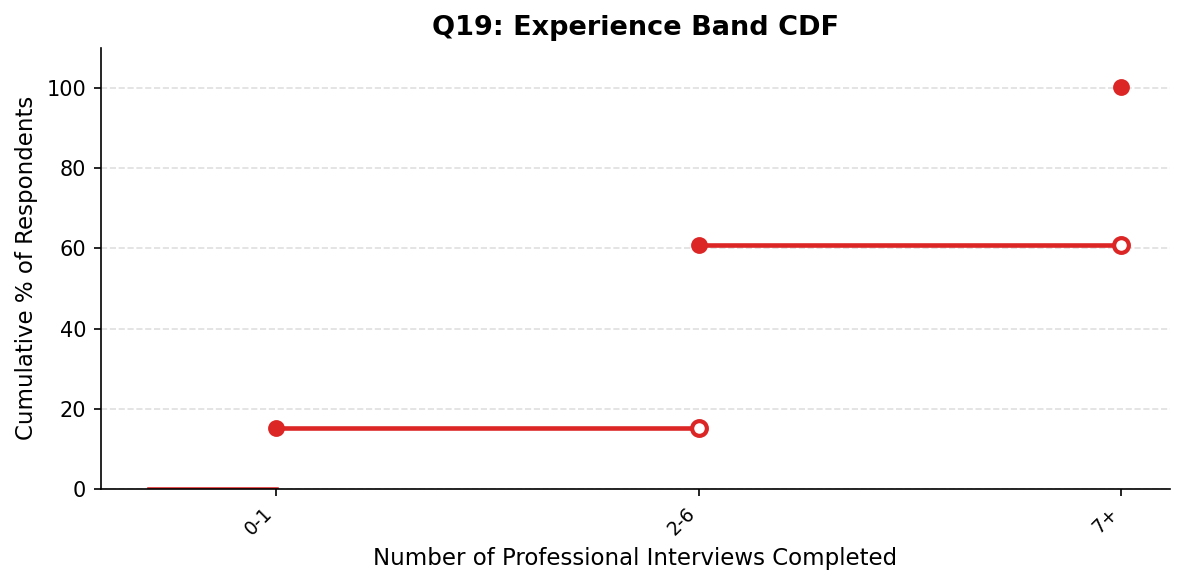

In [31]:
cum_pct = band_pct.cumsum()
x_pos = list(range(len(band_order)))

fig, ax = plt.subplots(figsize=(8, 4))

# Draw only horizontal segments (no verticals)
for i in range(len(x_pos) - 1):
    ax.plot([x_pos[i], x_pos[i+1]], [cum_pct.iloc[i], cum_pct.iloc[i]], 
            color=AGENT_COLOR, linewidth=2.2)

# Flat line extending left of the first point
ax.plot([-0.3, 0], [0, 0], color=AGENT_COLOR, linewidth=2.2)

# Filled dots
ax.scatter(x_pos, cum_pct, color=AGENT_COLOR, s=50, zorder=5)

# Open circles
ax.scatter(x_pos[1:], cum_pct[:-1],
           facecolors='white', edgecolors=AGENT_COLOR, s=50, linewidths=2, zorder=5)

ax.set_xticks(x_pos)
ax.set_xticklabels(band_order, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Number of Professional Interviews Completed')
ax.set_ylabel('Cumulative % of Respondents')
ax.set_title('Q19: Experience Band CDF', fontweight='bold')
ax.set_ylim(0, 110)

ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('fig_h4_experience_distribution_cdf.png', bbox_inches='tight', dpi=150)
plt.show()

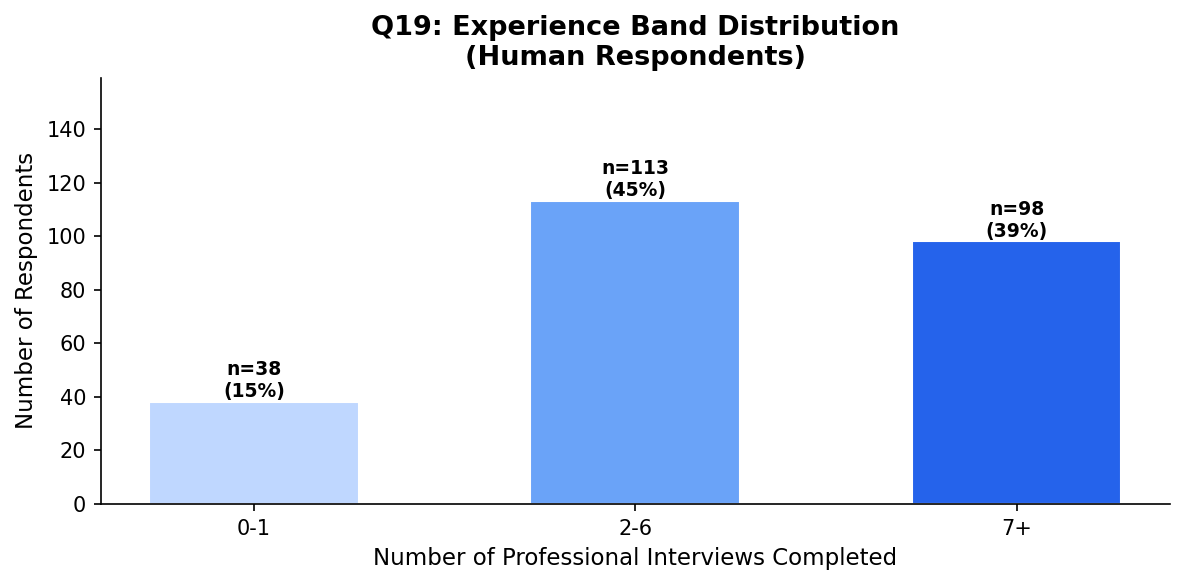

Saved: fig_h4_experience_distribution.png


In [32]:
# ── Figure 1: Experience band distribution ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(band_order, band_counts.values, color=BAND_COLORS, width=0.55, edgecolor='white')
ax.set_xlabel('Number of Professional Interviews Completed')
ax.set_ylabel('Number of Respondents')
ax.set_title('Q19: Experience Band Distribution\n(Human Respondents)', fontweight='bold')
for bar, n, pct in zip(bars, band_counts.values, band_pct.values):
    if n > 0:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'n={n}\n({pct:.0f}%)', ha='center', va='bottom', fontsize=9, fontweight='bold')
max_n = max(band_counts.values) if max(band_counts.values) > 0 else 5
ax.set_ylim(0, max_n * 1.4 + 1)
plt.tight_layout()
plt.savefig('fig_h4_experience_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h4_experience_distribution.png')

---
## 4. Experience Band × Peer Cheating Estimate (Q19 × Q2)

Tests the **social learning mechanism**: more experienced candidates should estimate higher peer cheating rates, reflecting larger reference networks and accumulated exposure to cheating incidents.

> *"Respondents in the 0–1 band estimated on average that [X]% of job-seekers they know have cheated, while respondents in the 2–6 band estimated [X]%, and those with 7+ interviews estimated [X]%."*

In [33]:
# ── Fill-in computations ───────────────────────────────────────────────────────
peer_by_band = df.groupby('exp_band')['q2_pct_n'].agg(['mean','median','std','count'])
peer_by_band = peer_by_band.reindex(band_order)

print('── Q2 Peer Cheating Estimate by Experience Band ──')
print(peer_by_band.round(2).to_string())

# Kruskal-Wallis test across bands
groups = [df.loc[df['exp_band']==b, 'q2_pct_n'].dropna().values for b in band_order]
groups_valid = [g for g in groups if len(g) >= 2]
if len(groups_valid) >= 2:
    stat_kw, pval_kw = stats.kruskal(*groups_valid)
    print(f'\nKruskal-Wallis H={stat_kw:.3f}, p={pval_kw:.3f}')
else:
    print('\nKruskal-Wallis: insufficient group sizes — will compute with full sample.')

# Spearman correlation: experience band order vs peer estimate
df_corr = df.dropna(subset=['exp_band','q2_pct_n']).copy()
df_corr['exp_band_n'] = df_corr['exp_band'].map({b: i for i, b in enumerate(band_order)})
if len(df_corr) >= 3:
    rho, pval = stats.spearmanr(df_corr['exp_band_n'], df_corr['q2_pct_n'])
    print(f'Spearman r (experience vs peer estimate): r={rho:.3f}, p={pval:.3f}')
else:
    print(f'Spearman r: {len(df_corr)} obs — will compute with full sample.')

print('\n── [X] FILL-IN VALUES FOR LATEX ──')
for band in ['0-1', '2-6']:
    v = peer_by_band.loc[band, 'mean'] if band in peer_by_band.index else np.nan
    print(f'  {band} band mean peer estimate: {v:.2f}%' if not np.isnan(v) else f'  {band} band: [no data]')
v7p = peer_by_band.loc[['7+'], 'mean'].mean() if any(b in peer_by_band.index for b in ['7+']) else np.nan
print(f'  7+ band mean peer estimate    : {v7p:.2f}%' if not np.isnan(v7p) else '  7+ band: [no data]')

── Q2 Peer Cheating Estimate by Experience Band ──
           mean  median    std  count
exp_band                             
0-1       35.29    35.0  16.71     38
2-6       34.65    30.0  22.08    113
7+        39.71    35.0  23.13     98

Kruskal-Wallis H=2.761, p=0.251
Spearman r (experience vs peer estimate): r=0.076, p=0.233

── [X] FILL-IN VALUES FOR LATEX ──
  0-1 band mean peer estimate: 35.29%
  2-6 band mean peer estimate: 34.65%
  7+ band mean peer estimate    : 39.71%


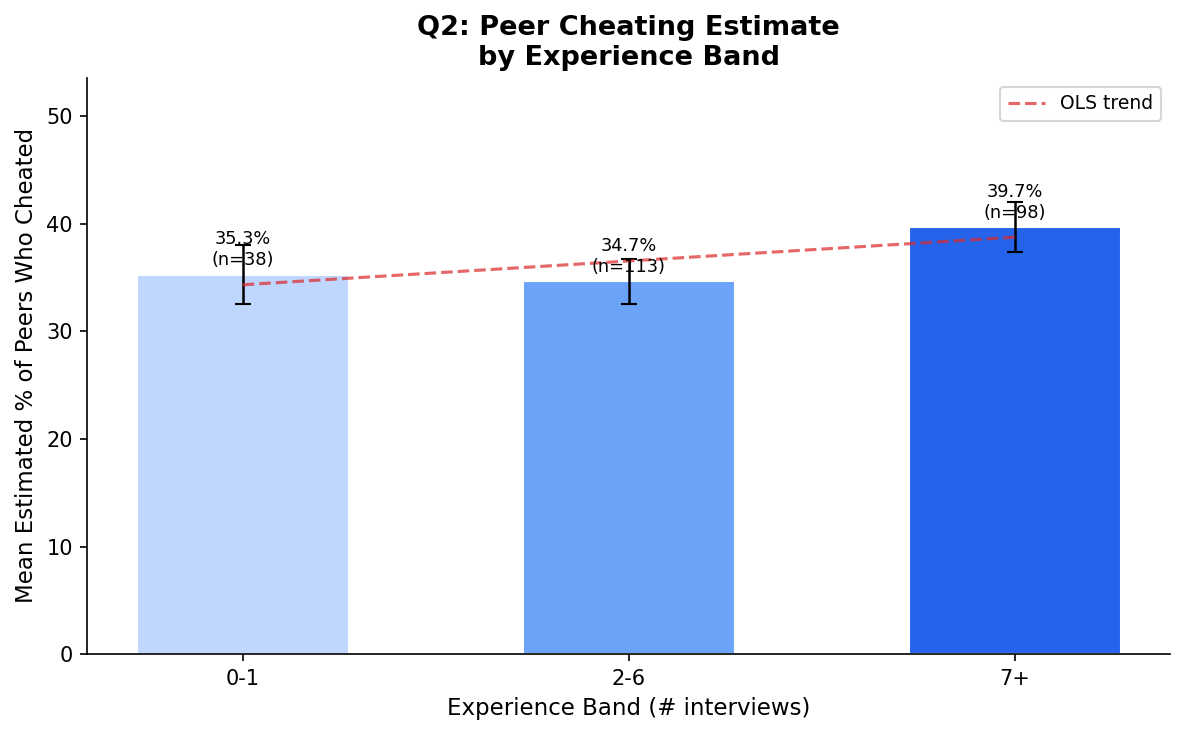

Saved: fig_h4_peer_estimate_by_experience_means.png


In [34]:
# ── Figure 2a: Experience band × peer estimate (means with error bars) ────────
fig, ax = plt.subplots(figsize=(8, 5))

means = peer_by_band['mean'].values
sems  = (peer_by_band['std'] / np.sqrt(peer_by_band['count'])).values
bars  = ax.bar(band_order, means, color=BAND_COLORS, width=0.55, edgecolor='white')
ax.errorbar(band_order, means, yerr=sems, fmt='none', color='black', capsize=4, linewidth=1.2)
ax.set_xlabel('Experience Band (# interviews)')
ax.set_ylabel('Mean Estimated % of Peers Who Cheated')
ax.set_title('Q2: Peer Cheating Estimate\nby Experience Band', fontweight='bold')
max_v = np.nanmax(means) if not all(np.isnan(means)) else 10
ax.set_ylim(0, max(max_v * 1.35, 10))
for bar, mean, n in zip(bars, means, peer_by_band['count'].values):
    if not np.isnan(mean):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                f'{mean:.1f}%\n(n={int(n)})', ha='center', va='bottom', fontsize=8.5)

# Trend line
valid_idx = [i for i, m in enumerate(means) if not np.isnan(m)]
if len(valid_idx) >= 2:
    xs = np.array(valid_idx)
    ys = np.array([means[i] for i in valid_idx])
    m_line, b_line, *_ = stats.linregress(xs, ys)
    ax.plot(np.arange(len(band_order)), m_line*np.arange(len(band_order))+b_line,
            color=AGENT_COLOR, linestyle='--', linewidth=1.5, alpha=0.7, label='OLS trend')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('fig_h4_peer_estimate_by_experience_means.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h4_peer_estimate_by_experience_means.png')


---
## 5. Experience Band × Willingness to Cheat (Q19 × Q13a)

Tests the main H4 gradient. Also checks whether the gradient persists *after controlling for Q2 peer estimates* — if so, supports moral disengagement over pure social learning.

> *"Respondents with 7+ interviews were [X] times more likely to report being 'Somewhat Likely' or 'Extremely Likely'... The 2–6 band fell between at [X] times more likely."*

In [35]:
# ── Fill-in computations ───────────────────────────────────────────────────────
will_by_band = df.groupby('exp_band').agg(
    mean_willing=('q13a_willing_n', 'mean'),
    pct_willing=('willing_high_flag', 'mean'),
    n=('q13a_willing_n', 'count')
).reindex(band_order)
will_by_band['pct_willing_pct'] = (will_by_band['pct_willing'] * 100).round(1)

print('── Q13a Willingness Rate by Experience Band ──')
print(will_by_band.round(3).to_string())

# Relative likelihood ratios vs 0-1 band
base_rate = will_by_band.loc['0-1', 'pct_willing'] if '0-1' in will_by_band.index else np.nan
print('\n── Likelihood ratios vs 0-1 band ──')
for band in ['2-6', '7+']:
    r = will_by_band.loc[band, 'pct_willing'] if band in will_by_band.index else np.nan
    ratio = r / base_rate if (not np.isnan(base_rate) and not np.isnan(r) and base_rate > 0) else np.nan
    print(f'  {band} band vs 0-1: {ratio:.2f}x' if not np.isnan(ratio) else f'  {band} band: [no data or base rate = 0]')

# Spearman correlation: experience band vs willingness
df_w = df.dropna(subset=['exp_band','q13a_willing_n']).copy()
df_w['exp_band_n'] = df_w['exp_band'].map({b: i for i, b in enumerate(band_order)})
if len(df_w) >= 3:
    rho_w, pval_w = stats.spearmanr(df_w['exp_band_n'], df_w['q13a_willing_n'])
    print(f'\nSpearman r (experience band vs Q13a willingness): r={rho_w:.3f}, p={pval_w:.3f}')
else:
    print(f'\nSpearman r: {len(df_w)} obs — will compute with full sample.')

# Partial correlation: experience vs willingness controlling for Q2
df_partial = df.dropna(subset=['exp_band','q13a_willing_n','q2_pct_n']).copy()
df_partial['exp_band_n'] = df_partial['exp_band'].map({b: i for i, b in enumerate(band_order)})
if len(df_partial) >= 4:
    # Residualize willingness on Q2, then correlate with experience
    resid = stats.linregress(df_partial['q2_pct_n'], df_partial['q13a_willing_n'])
    df_partial['q13a_resid'] = (df_partial['q13a_willing_n']
                                 - (resid.slope * df_partial['q2_pct_n'] + resid.intercept))
    rho_partial, pval_partial = stats.spearmanr(df_partial['exp_band_n'], df_partial['q13a_resid'])
    print(f'Partial r (experience vs willingness, controlling for Q2): r={rho_partial:.3f}, p={pval_partial:.3f}')
    print('  (If still significant: experience has independent effect → supports moral disengagement)')
else:
    print(f'Partial correlation: {len(df_partial)} obs — will compute with full sample.')

print('\n── [X] FILL-IN VALUES FOR LATEX ──')
for band in band_order:
    if band in will_by_band.index:
        print(f'  {band} band: mean willingness={will_by_band.loc[band,"mean_willing"]:.2f}, '
              f'pct willing={will_by_band.loc[band,"pct_willing_pct"]:.1f}%, n={int(will_by_band.loc[band,"n"]) if not np.isnan(will_by_band.loc[band,"n"]) else "n/a"}')

── Q13a Willingness Rate by Experience Band ──
          mean_willing  pct_willing    n  pct_willing_pct
exp_band                                                 
0-1              3.316        0.605   38             60.5
2-6              3.133        0.522  113             52.2
7+               3.306        0.561   98             56.1

── Likelihood ratios vs 0-1 band ──
  2-6 band vs 0-1: 0.86x
  7+ band vs 0-1: 0.93x

Spearman r (experience band vs Q13a willingness): r=0.028, p=0.655
Partial r (experience vs willingness, controlling for Q2): r=0.013, p=0.838
  (If still significant: experience has independent effect → supports moral disengagement)

── [X] FILL-IN VALUES FOR LATEX ──
  0-1 band: mean willingness=3.32, pct willing=60.5%, n=38
  2-6 band: mean willingness=3.13, pct willing=52.2%, n=113
  7+ band: mean willingness=3.31, pct willing=56.1%, n=98


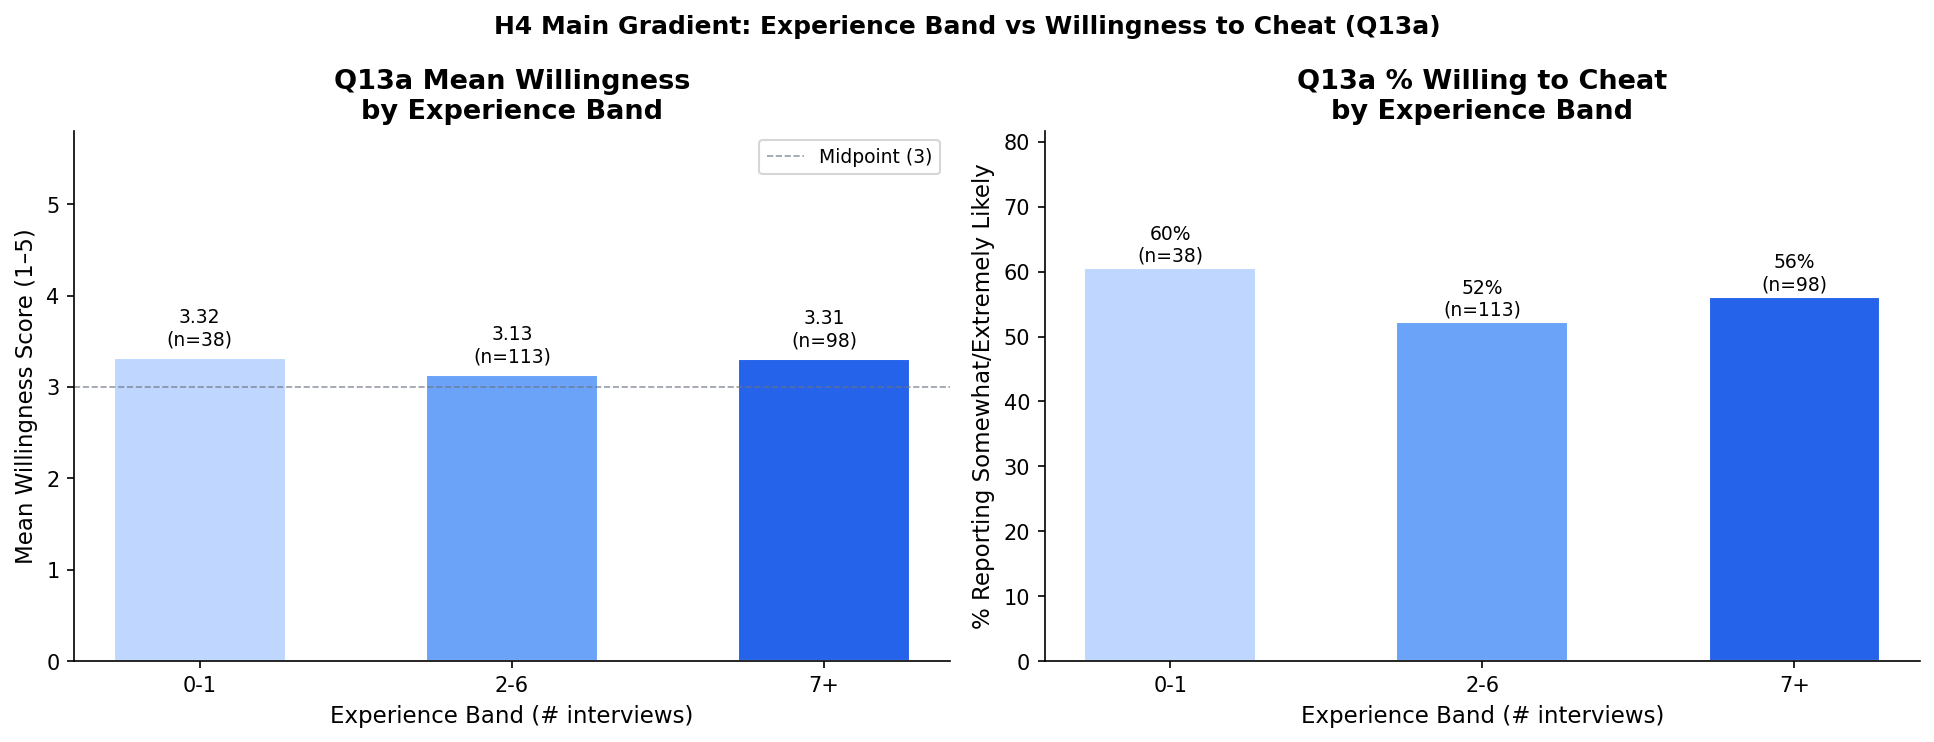

Saved: fig_h4_willingness_by_experience.png


In [36]:
# ── Figure 3: Experience band × willingness ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: mean willingness score by band
ax = axes[0]
means_w = will_by_band['mean_willing'].values
bars = ax.bar(band_order, means_w, color=BAND_COLORS, width=0.55, edgecolor='white')
ax.axhline(3, linestyle='--', color=NEUTRAL_COLOR, linewidth=0.8, alpha=0.7, label='Midpoint (3)')
ax.set_ylim(0, 5.8)
ax.set_xlabel('Experience Band (# interviews)')
ax.set_ylabel('Mean Willingness Score (1–5)')
ax.set_title('Q13a Mean Willingness\nby Experience Band', fontweight='bold')
for bar, m, n in zip(bars, means_w, will_by_band['n'].values):
    if not np.isnan(m):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                f'{m:.2f}\n(n={int(n)})', ha='center', va='bottom', fontsize=9)
ax.legend(fontsize=9)

# Right: % willing (Somewhat/Extremely Likely) by band
ax2 = axes[1]
pcts = will_by_band['pct_willing_pct'].values
bars2 = ax2.bar(band_order, pcts, color=BAND_COLORS, width=0.55, edgecolor='white')
ax2.set_ylim(0, max(np.nanmax(pcts) * 1.35 if not all(np.isnan(pcts)) else 10, 15))
ax2.set_xlabel('Experience Band (# interviews)')
ax2.set_ylabel('% Reporting Somewhat/Extremely Likely')
ax2.set_title('Q13a % Willing to Cheat\nby Experience Band', fontweight='bold')
for bar, p, n in zip(bars2, pcts, will_by_band['n'].values):
    if not np.isnan(p):
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{p:.0f}%\n(n={int(n)})', ha='center', va='bottom', fontsize=9)

plt.suptitle('H4 Main Gradient: Experience Band vs Willingness to Cheat (Q13a)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h4_willingness_by_experience.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h4_willingness_by_experience.png')

---
## 6. Experience Band × Acceptability (Q19 × Q3)

Tests the **moral disengagement mechanism** specifically: if experience shifts acceptability ratings independently of willingness, that supports Bandura's account.

> *"More experienced respondents assigned higher acceptability scores to [X] and [X] behaviors than less experienced respondents, though the gap was smallest for live behind-the-scenes assistance."*

In [37]:
# ── Fill-in computations ───────────────────────────────────────────────────────
accept_by_band = {}
for col, lbl in zip(accept_n_cols, accept_labels):
    grp = df.groupby('exp_band')[col].mean().reindex(band_order)
    accept_by_band[lbl.replace('\n',' ')] = grp

accept_band_df = pd.DataFrame(accept_by_band).T
print('── Q3 Mean Acceptability by Experience Band ──')
print(accept_band_df.round(2).to_string())

# Which behaviors show the largest experience gradient?
print('\n── Experience gradient (7+ mean minus 0-1 mean, per behavior) ──')
if '7+' in band_order and '0-1' in band_order:
    for lbl in accept_band_df.index:
        v_high = accept_band_df.loc[lbl, '7+'] if '7+' in accept_band_df.columns else np.nan
        v_low  = accept_band_df.loc[lbl, '0-1'] if '0-1' in accept_band_df.columns else np.nan
        diff   = v_high - v_low if not (np.isnan(v_high) or np.isnan(v_low)) else np.nan
        print(f'  {lbl:<35}: Δ={diff:.2f}' if not np.isnan(diff) else f'  {lbl}: [no data]')

print('\n── [X] FILL-IN VALUES FOR LATEX ──')
print('  Two behaviors with largest experience gradient:')
if '7+' in accept_band_df.columns and '0-1' in accept_band_df.columns:
    diffs = (accept_band_df['7+'] - accept_band_df['0-1']).dropna().sort_values(ascending=False)
    for lbl, d in diffs.head(2).items():
        print(f'    {lbl}: Δ={d:.2f}')
    live_diff = accept_band_df.loc['Live Assist Behind Scenes', '7+'] - accept_band_df.loc['Live Assist Behind Scenes', '0-1'] \
                if ('Live Assist Behind Scenes' in accept_band_df.index) else np.nan
    print(f'  Live assist gap (smallest): Δ={live_diff:.2f}' if not np.isnan(live_diff) else '  Live assist: [no data]')

── Q3 Mean Acceptability by Experience Band ──
exp_band                    0-1   2-6    7+
AI During Interview        2.62  1.99  2.26
Search Engine During       3.08  2.68  2.72
Questions Beforehand       3.27  3.12  3.08
Live Assist Behind Scenes  1.76  1.57  1.50
Handwritten Notes          4.47  4.42  4.26
AI-Generated Notes         3.51  3.47  3.62

── Experience gradient (7+ mean minus 0-1 mean, per behavior) ──
  AI During Interview                : Δ=-0.36
  Search Engine During               : Δ=-0.36
  Questions Beforehand               : Δ=-0.19
  Live Assist Behind Scenes          : Δ=-0.26
  Handwritten Notes                  : Δ=-0.21
  AI-Generated Notes                 : Δ=0.11

── [X] FILL-IN VALUES FOR LATEX ──
  Two behaviors with largest experience gradient:
    AI-Generated Notes: Δ=0.11
    Questions Beforehand: Δ=-0.19
  Live assist gap (smallest): Δ=-0.26


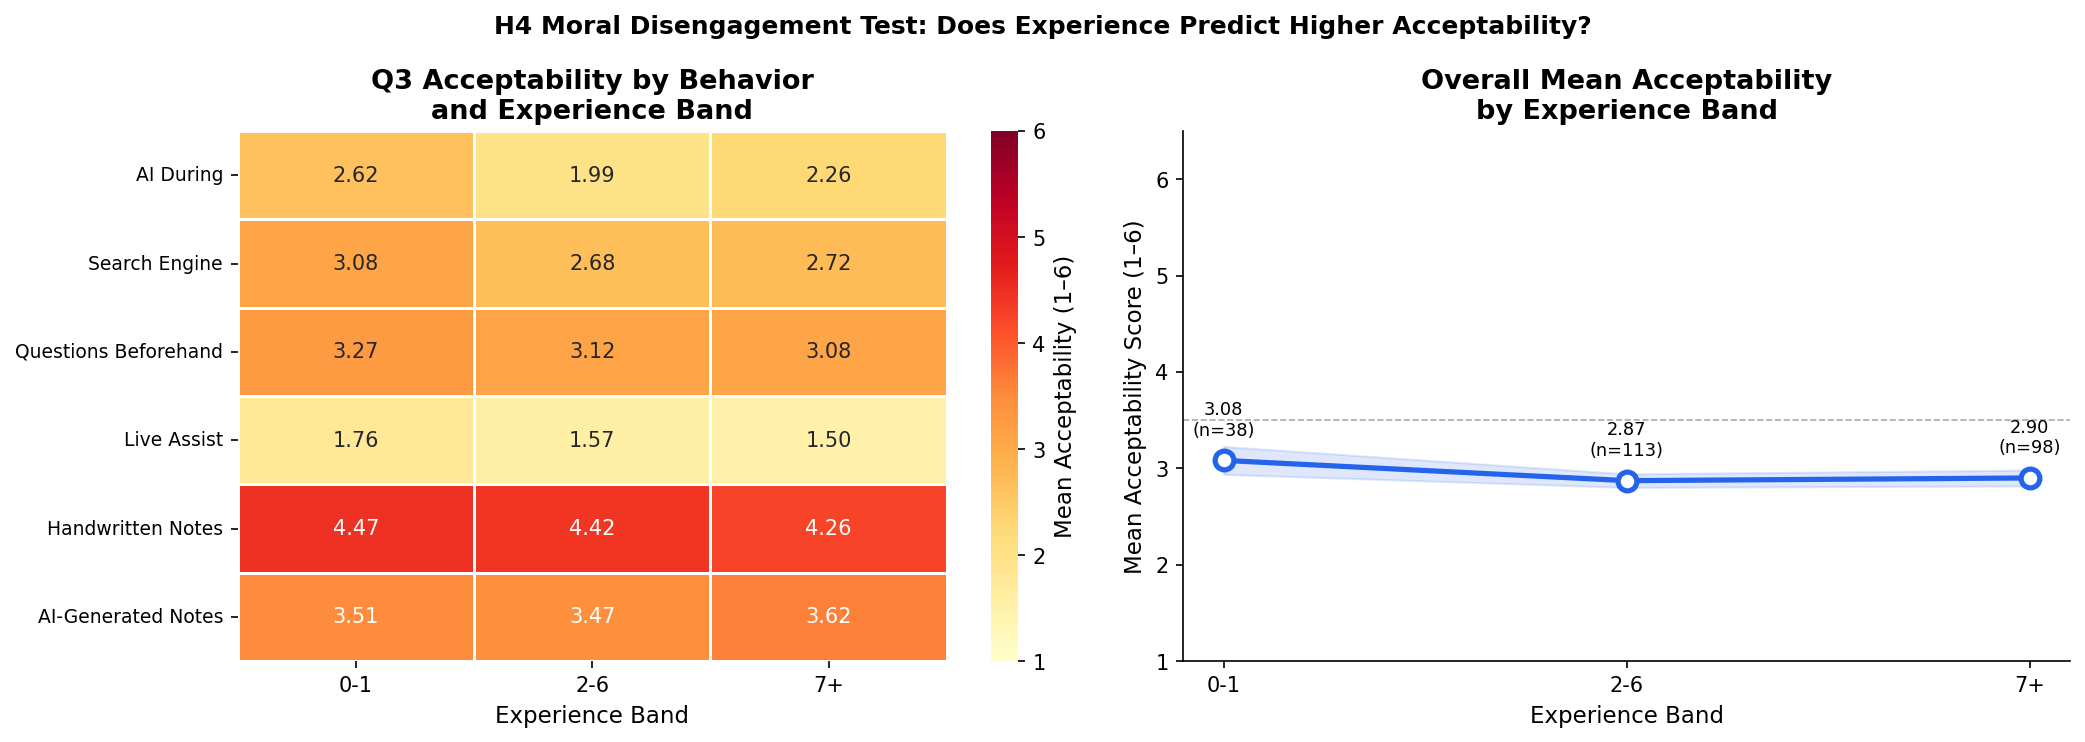

Saved: fig_h4_acceptability_by_experience.png


In [38]:
# ── Figure 4: Heatmap — acceptability by experience band × behavior ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: heatmap
ax = axes[0]
heatmap_data = accept_band_df[band_order] if all(b in accept_band_df.columns for b in band_order) \
               else accept_band_df.reindex(columns=band_order)
short_labels_h = ['AI During', 'Search Engine', 'Questions Beforehand',
                  'Live Assist', 'Handwritten Notes', 'AI-Generated Notes']
heatmap_data.index = short_labels_h

if not heatmap_data.isna().all().all():
    sns.heatmap(heatmap_data.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
                vmin=1, vmax=6, ax=ax, linewidths=0.5,
                cbar_kws={'label': 'Mean Acceptability (1–6)'})
    ax.set_title('Q3 Acceptability by Behavior\nand Experience Band', fontweight='bold')
    ax.set_xlabel('Experience Band')
    ax.tick_params(axis='y', rotation=0, labelsize=9)
else:
    ax.text(0.5, 0.5, 'Awaiting data', ha='center', va='center',
            transform=ax.transAxes, fontsize=13, color=NEUTRAL_COLOR)
    ax.set_title('Q3 Acceptability Heatmap', fontweight='bold')

# Right: line chart — mean acceptability per band across all behaviors
ax2 = axes[1]
mean_accept_by_band = df.groupby('exp_band')['q3_mean_accept'].mean().reindex(band_order)
sem_accept_by_band  = (df.groupby('exp_band')['q3_mean_accept'].std() /
                       df.groupby('exp_band')['q3_mean_accept'].count().pow(0.5)).reindex(band_order)

valid_bands = [b for b in band_order if not np.isnan(mean_accept_by_band.get(b, np.nan))]
if len(valid_bands) >= 2:
    xs = range(len(band_order))
    ax2.plot(list(xs), mean_accept_by_band.values, marker='o', linewidth=2.5,
             color=HUMAN_COLOR, markersize=9, markerfacecolor='white',
             markeredgewidth=2.5, label='Mean acceptability')
    ax2.fill_between(list(xs),
                     mean_accept_by_band.values - sem_accept_by_band.values,
                     mean_accept_by_band.values + sem_accept_by_band.values,
                     alpha=0.15, color=HUMAN_COLOR)
    for i, (m, n) in enumerate(zip(mean_accept_by_band.values,
                                    df.groupby('exp_band')['q3_mean_accept'].count().reindex(band_order).values)):
        if not np.isnan(m):
            ax2.annotate(f'{m:.2f}\n(n={int(n)})', (i, m), textcoords='offset points',
                         xytext=(0, 12), ha='center', fontsize=8.5)
else:
    ax2.text(0.5, 0.5, 'Awaiting data', ha='center', va='center',
             transform=ax2.transAxes, fontsize=13, color=NEUTRAL_COLOR)
ax2.set_xticks(range(len(band_order)))
ax2.set_xticklabels(band_order, fontsize=10)
ax2.axhline(3.5, linestyle='--', color=NEUTRAL_COLOR, linewidth=0.8, alpha=0.6)
ax2.set_ylim(1, 6.5)
ax2.set_xlabel('Experience Band')
ax2.set_ylabel('Mean Acceptability Score (1–6)')
ax2.set_title('Overall Mean Acceptability\nby Experience Band', fontweight='bold')

plt.suptitle('H4 Moral Disengagement Test: Does Experience Predict Higher Acceptability?',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h4_acceptability_by_experience.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h4_acceptability_by_experience.png')

---
## 7. Willingness Profiles (Q13a × Q14a)

Respondents are classified into five behavioral profiles based on their responses to Q13a (high peer cheating) and Q14a (no peer cheating):

| Profile | Q14a (No peer) | Q13a (High peer) |
|---|---|---|
| **Unwilling** | Unlikely | Unlikely |
| **Conditionally Willing** | Unlikely | Likely |
| **Indifferent** | Neither | Neither |
| **Generally Willing** | Likely | Likely |
| **Contrarian** | Likely | Unlikely |

In [39]:
# ── Profile assignment ─────────────────────────────────────────────────────────
def assign_profile(row):
    h = row['q13a_willing_n']  # high peer condition
    n = row['q14a_willing_n']  # no peer condition
    if pd.isna(h) or pd.isna(n):
        return np.nan
    h_likely   = h >= 4
    h_unlikely = h <= 2
    h_neither  = h == 3
    n_likely   = n >= 4
    n_unlikely = n <= 2
    n_neither  = n == 3

    if h_unlikely and n_unlikely:
        return 'Unwilling'
    elif h_likely and n_unlikely:
        return 'Conditionally Willing'
    elif h_neither and n_neither:
        return 'Indifferent'
    elif h_likely and n_likely:
        return 'Generally Willing'
    elif h_unlikely and n_likely:
        return 'Contrarian'
    else:
        return 'Mixed'

df['profile'] = df.apply(assign_profile, axis=1)

profile_order = ['Unwilling','Conditionally Willing','Indifferent','Generally Willing','Contrarian','Mixed']
profile_colors = {'Unwilling'             : '#1D4ED8',
                  'Conditionally Willing' : '#60A5FA',
                  'Indifferent'           : '#9CA3AF',
                  'Generally Willing'     : '#DC2626',
                  'Contrarian'            : '#7C3AED',
                  'Mixed'                 : '#D1D5DB'}

profile_counts = df['profile'].value_counts().reindex(profile_order, fill_value=0)
profile_pct    = (profile_counts / profile_counts.sum() * 100).round(1)

print('── Willingness Profile Distribution ──')
for p in profile_order:
    print(f'  {p:<22}: n={profile_counts[p]:>3}  ({profile_pct[p]:.1f}%)')
print(f'  Total profiled: {profile_counts.sum()}')

── Willingness Profile Distribution ──
  Unwilling             : n= 71  (28.5%)
  Conditionally Willing : n=107  (43.0%)
  Indifferent           : n=  8  (3.2%)
  Generally Willing     : n= 14  (5.6%)
  Contrarian            : n=  0  (0.0%)
  Mixed                 : n= 49  (19.7%)
  Total profiled: 249


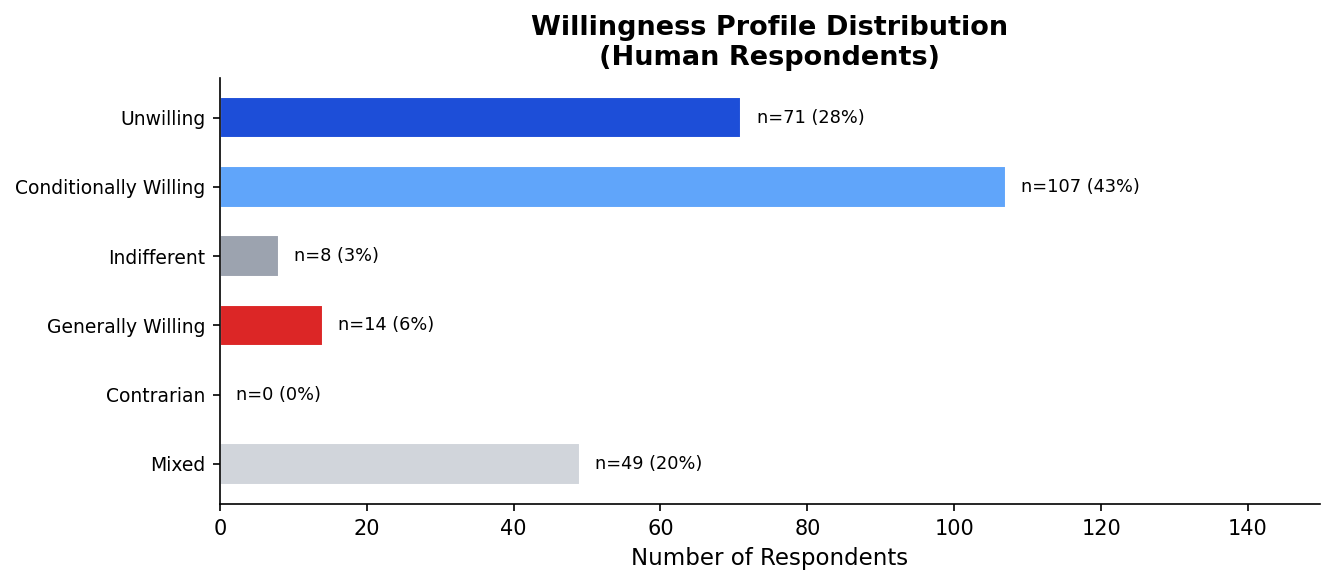

Saved: fig_h4_profile_distribution_horizontal.png


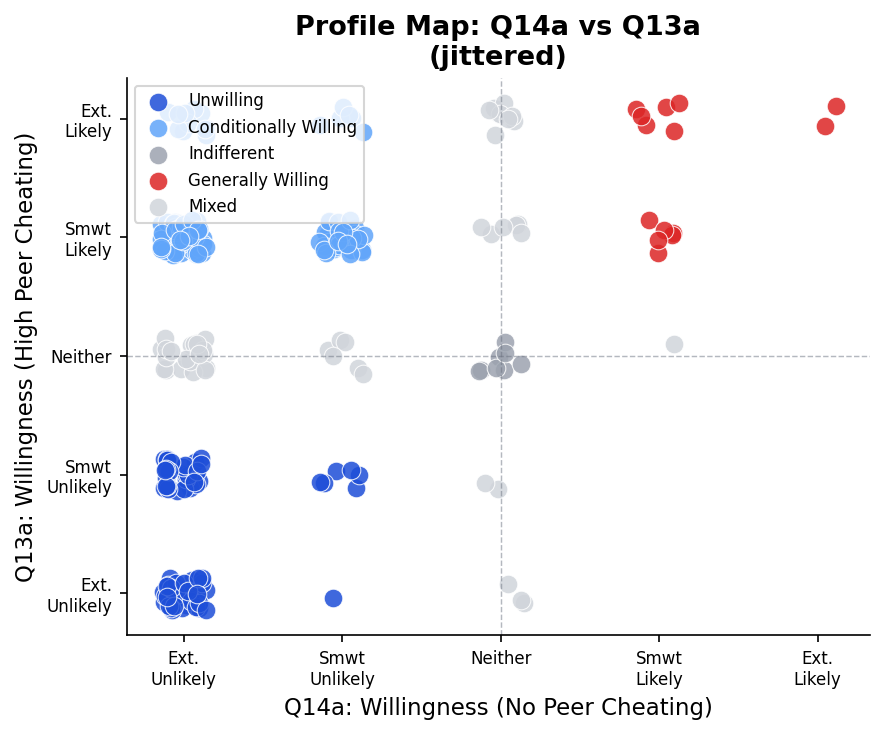

Saved: fig_h4_willingness_profiles_scatter.png


In [40]:
# ── Figure 5a: Profile distribution (horizontal bar chart) ───────────────────
profile_labels = profile_order
profile_values = [profile_counts[p] for p in profile_labels]
profile_colors_plot = [profile_colors[p] for p in profile_labels]

fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(profile_labels))
bars = ax.barh(y, profile_values, color=profile_colors_plot, edgecolor='white', height=0.6)
ax.set_yticks(y)
ax.set_yticklabels(profile_labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Number of Respondents')
ax.set_title('Willingness Profile Distribution\n(Human Respondents)', fontweight='bold')
max_n = max(profile_values) if len(profile_values) > 0 else 5
ax.set_xlim(0, max_n * 1.4)
for bar, p in zip(bars, profile_labels):
    n = profile_counts[p]
    ax.text(bar.get_width() + max_n * 0.02, bar.get_y() + bar.get_height() / 2,
            f'n={n} ({profile_pct[p]:.0f}%)', va='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('fig_h4_profile_distribution_horizontal.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h4_profile_distribution_horizontal.png')

# ── Figure 5b: 2D scatter — Q14a vs Q13a, colored by profile ────────────────
fig, ax = plt.subplots(figsize=(6, 5))
df_prof = df.dropna(subset=['q14a_willing_n','q13a_willing_n','profile'])
if len(df_prof) > 0:
    rng = np.random.default_rng(42)
    jx = rng.uniform(-0.15, 0.15, len(df_prof))
    jy = rng.uniform(-0.15, 0.15, len(df_prof))
    for profile in profile_order:
        mask = df_prof['profile'] == profile
        if mask.sum() > 0:
            ax.scatter(df_prof.loc[mask,'q14a_willing_n'] + jx[mask.values],
                       df_prof.loc[mask,'q13a_willing_n'] + jy[mask.values],
                       color=profile_colors[profile], label=profile,
                       s=80, alpha=0.85, edgecolors='white', linewidth=0.5)
    ax.legend(fontsize=8, loc='upper left')
else:
    ax.text(0.5, 0.5, 'Awaiting data', ha='center', va='center',
            transform=ax.transAxes, fontsize=13, color=NEUTRAL_COLOR)

ax.set_xlabel('Q14a: Willingness (No Peer Cheating)')
ax.set_ylabel('Q13a: Willingness (High Peer Cheating)')
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(['Ext.\nUnlikely', 'Smwt\nUnlikely', 'Neither', 'Smwt\nLikely', 'Ext.\nLikely'], fontsize=8)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_yticklabels(['Ext.\nUnlikely', 'Smwt\nUnlikely', 'Neither', 'Smwt\nLikely', 'Ext.\nLikely'], fontsize=8)
ax.set_title('Profile Map: Q14a vs Q13a\n(jittered)', fontweight='bold')
ax.axhline(3, linestyle='--', color=NEUTRAL_COLOR, linewidth=0.7, alpha=0.5)
ax.axvline(3, linestyle='--', color=NEUTRAL_COLOR, linewidth=0.7, alpha=0.5)

plt.tight_layout()
plt.savefig('fig_h4_willingness_profiles_scatter.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h4_willingness_profiles_scatter.png')

---
## 8. Profile × Field of Study / Industry

> *"Computer Science and Finance respondents were overrepresented in the Conditionally Willing and Generally Willing groups... Education and Healthcare respondents were concentrated almost exclusively in the Unwilling group."*

In [41]:
# ── Cross-tab: profile × industry ─────────────────────────────────────────────
# Simplify industry labels for readability
industry_remap = {
    'Technology: Software / SaaS / AI'               : 'Tech',
    'Finance: Investment Banking'                     : 'Finance',
    'Finance: Private Equity / Hedge Fund'           : 'Finance',
    'Finance: Corporate Finance / Accounting'        : 'Finance',
    'Finance: FinTech'                               : 'Finance',
    'Consulting'                                     : 'Consulting',
    'Healthcare: Biotech / Pharma / Research'        : 'Healthcare',
    'Healthcare: Clinical / Hospital Administration' : 'Healthcare',
    'Education'                                      : 'Education',
    'Law'                                            : 'Law',
    'Marketing / Advertising / PR'                   : 'Marketing',
    'Engineering (non-software)'                     : 'Engineering',
    'Government / Public Policy'                     : 'Gov/Policy',
    'Non-profit / Social Impact'                     : 'Non-profit',
    'Media / Entertainment / Sports'                 : 'Media',
    'Real Estate'                                    : 'Real Estate',
    'Other'                                          : 'Other',
}
df['industry_simple'] = df['q17_industry'].map(industry_remap).fillna(
    df['q17_industry'].str.split(':').str[0].str.strip())

df_prof2 = df.dropna(subset=['profile','industry_simple'])
df_prof2 = df_prof2[df_prof2['profile'] != 'Mixed']

if len(df_prof2) > 0:
    # Cross-tab: industry × profile (column %)
    ct_ind = pd.crosstab(df_prof2['industry_simple'], df_prof2['profile'],
                         normalize='columns') * 100
    ct_ind = ct_ind.reindex(columns=[p for p in profile_order if p in ct_ind.columns])
    print('── Profile Distribution by Industry (column %) ──')
    print(ct_ind.round(1).to_string())

    # Cross-tab: industry × profile (row %) — shows within-industry profile mix
    ct_ind_row = pd.crosstab(df_prof2['industry_simple'], df_prof2['profile'],
                              normalize='index') * 100
    ct_ind_row = ct_ind_row.reindex(columns=[p for p in profile_order if p in ct_ind_row.columns])
    print('\n── Profile Mix Within Industry (row %) ──')
    print(ct_ind_row.round(1).to_string())
else:
    print('No data yet — cross-tab will populate with full sample.')

── Profile Distribution by Industry (column %) ──
profile                                   Unwilling  Conditionally Willing  Indifferent  Generally Willing
industry_simple                                                                                           
Consumer Goods / Retail / E-Commerce            1.4                    0.0          0.0                0.0
Education / Teaching                            8.5                    2.8          0.0                0.0
Energy / Utilities                              1.4                    2.8         12.5                7.1
Engineering                                     5.6                    8.4         12.5                7.1
Entertainment / Gaming / Creative Arts          2.8                    5.6          0.0                0.0
Finance                                         8.5                   13.1         12.5                7.1
Government / Public Sector                      5.6                    5.6          0.0       

In [42]:
other_responses = df[
    df['q16_field'].fillna('').str.contains('Other', case=False) |
    df['q17_industry'].fillna('').str.contains('Other', case=False)
]

other_responses[['q16_field', 'q16_field_other', 'q17_industry', 'q17_industry_other', 'profile']]


,q16_field,q16_field_other,q17_industry,q17_industry_other,profile
9,Other (please specify),Also Econ and MMSS,Other (please specify),Energy Economists,Conditionally Willing
25,Mathematics or Statistics,NaN,Other (please specify),Unsure,Mixed
26,Data Science / AI / Machine Learning,NaN,Other (please specify),Healthcare Consulting,Unwilling
27,Data Science / AI / Machine Learning,NaN,Other (please specify),Econ research,Conditionally Willing
28,Mathematics or Statistics,NaN,Other (please specify),Quant Trading,Conditionally Willing
29,Other (please specify),MMSS,Management Consulting,NaN,Unwilling
33,Other (please specify),MMSS,Finance: Asset Management / Hedge Funds,NaN,Conditionally Willing
35,Other (please specify),Industrial Engineering,Management Consulting,NaN,Conditionally Willing
39,Economics,NaN,Other (please specify),Don't Know,Unwilling
51,Other (please specify),Industrial Engineering,Management Consulting,NaN,Generally Willing


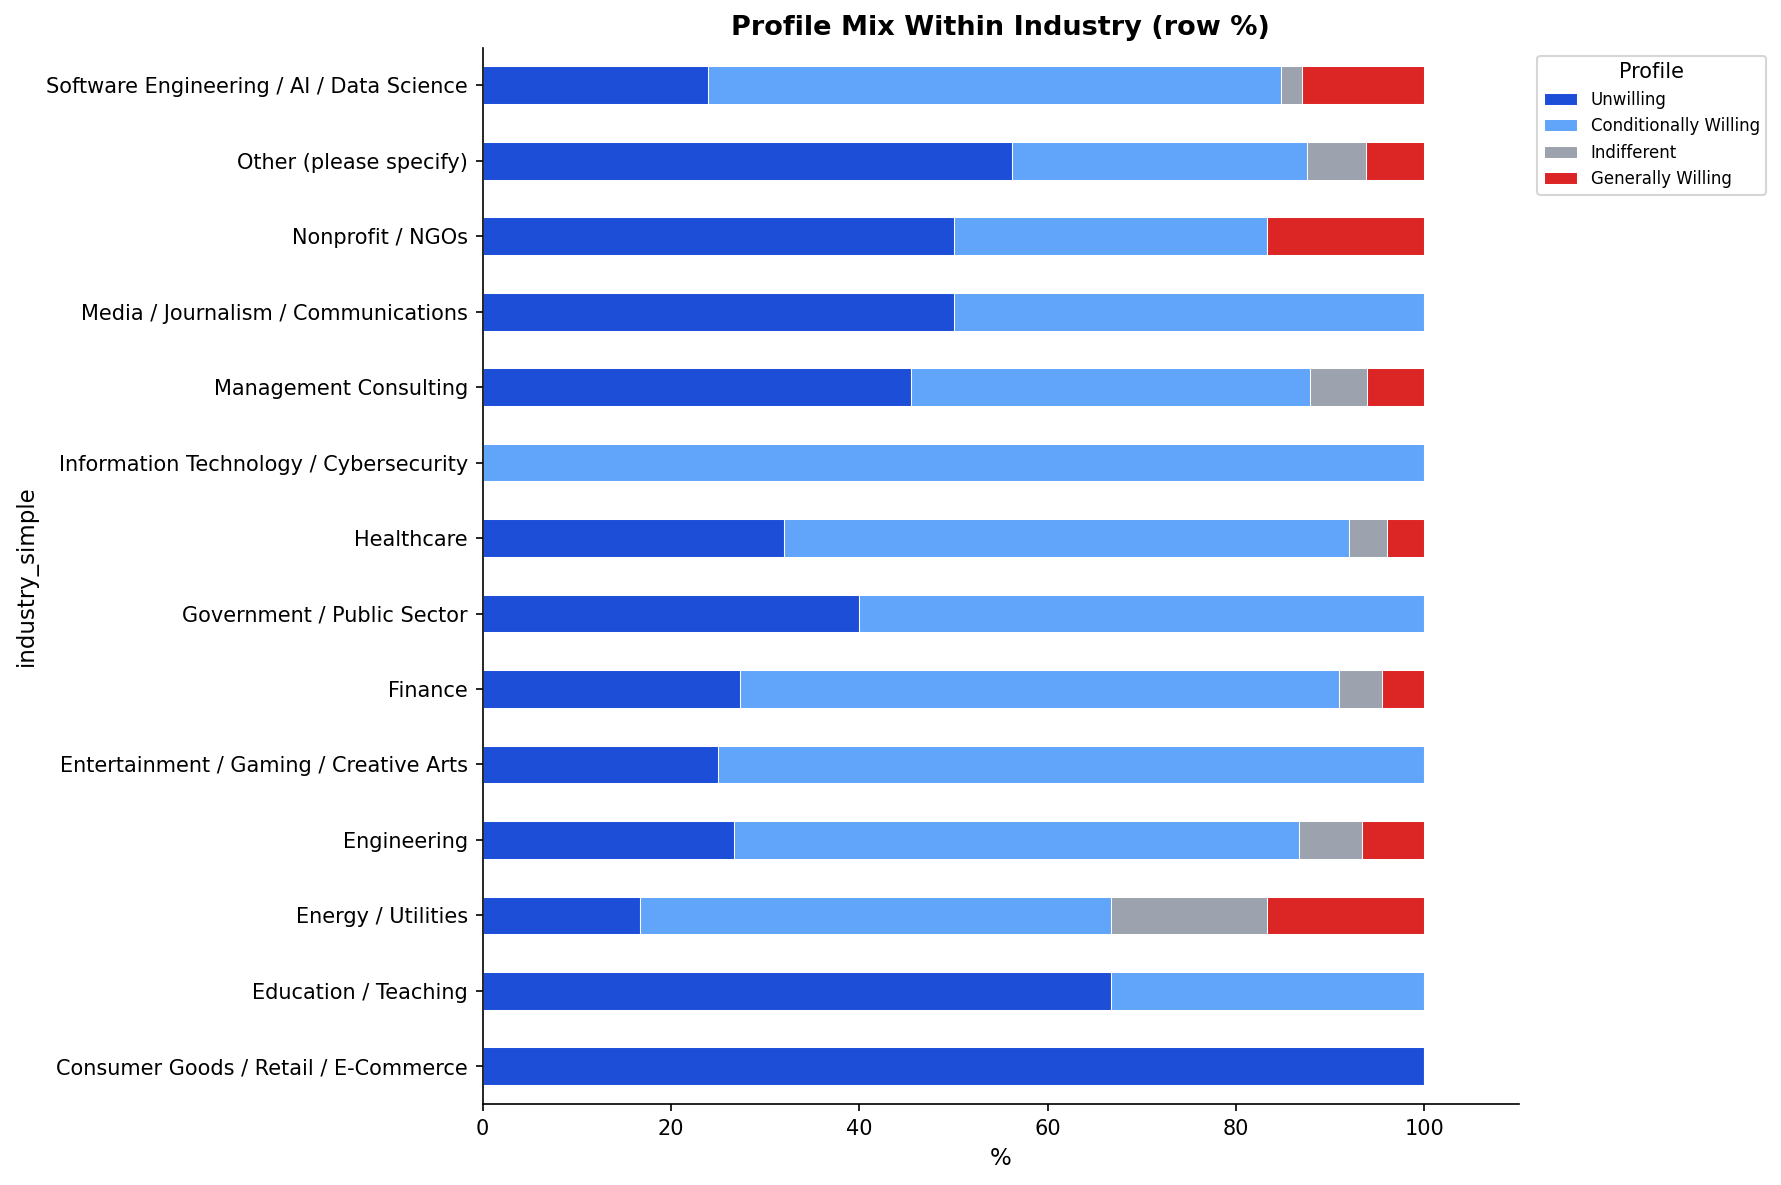

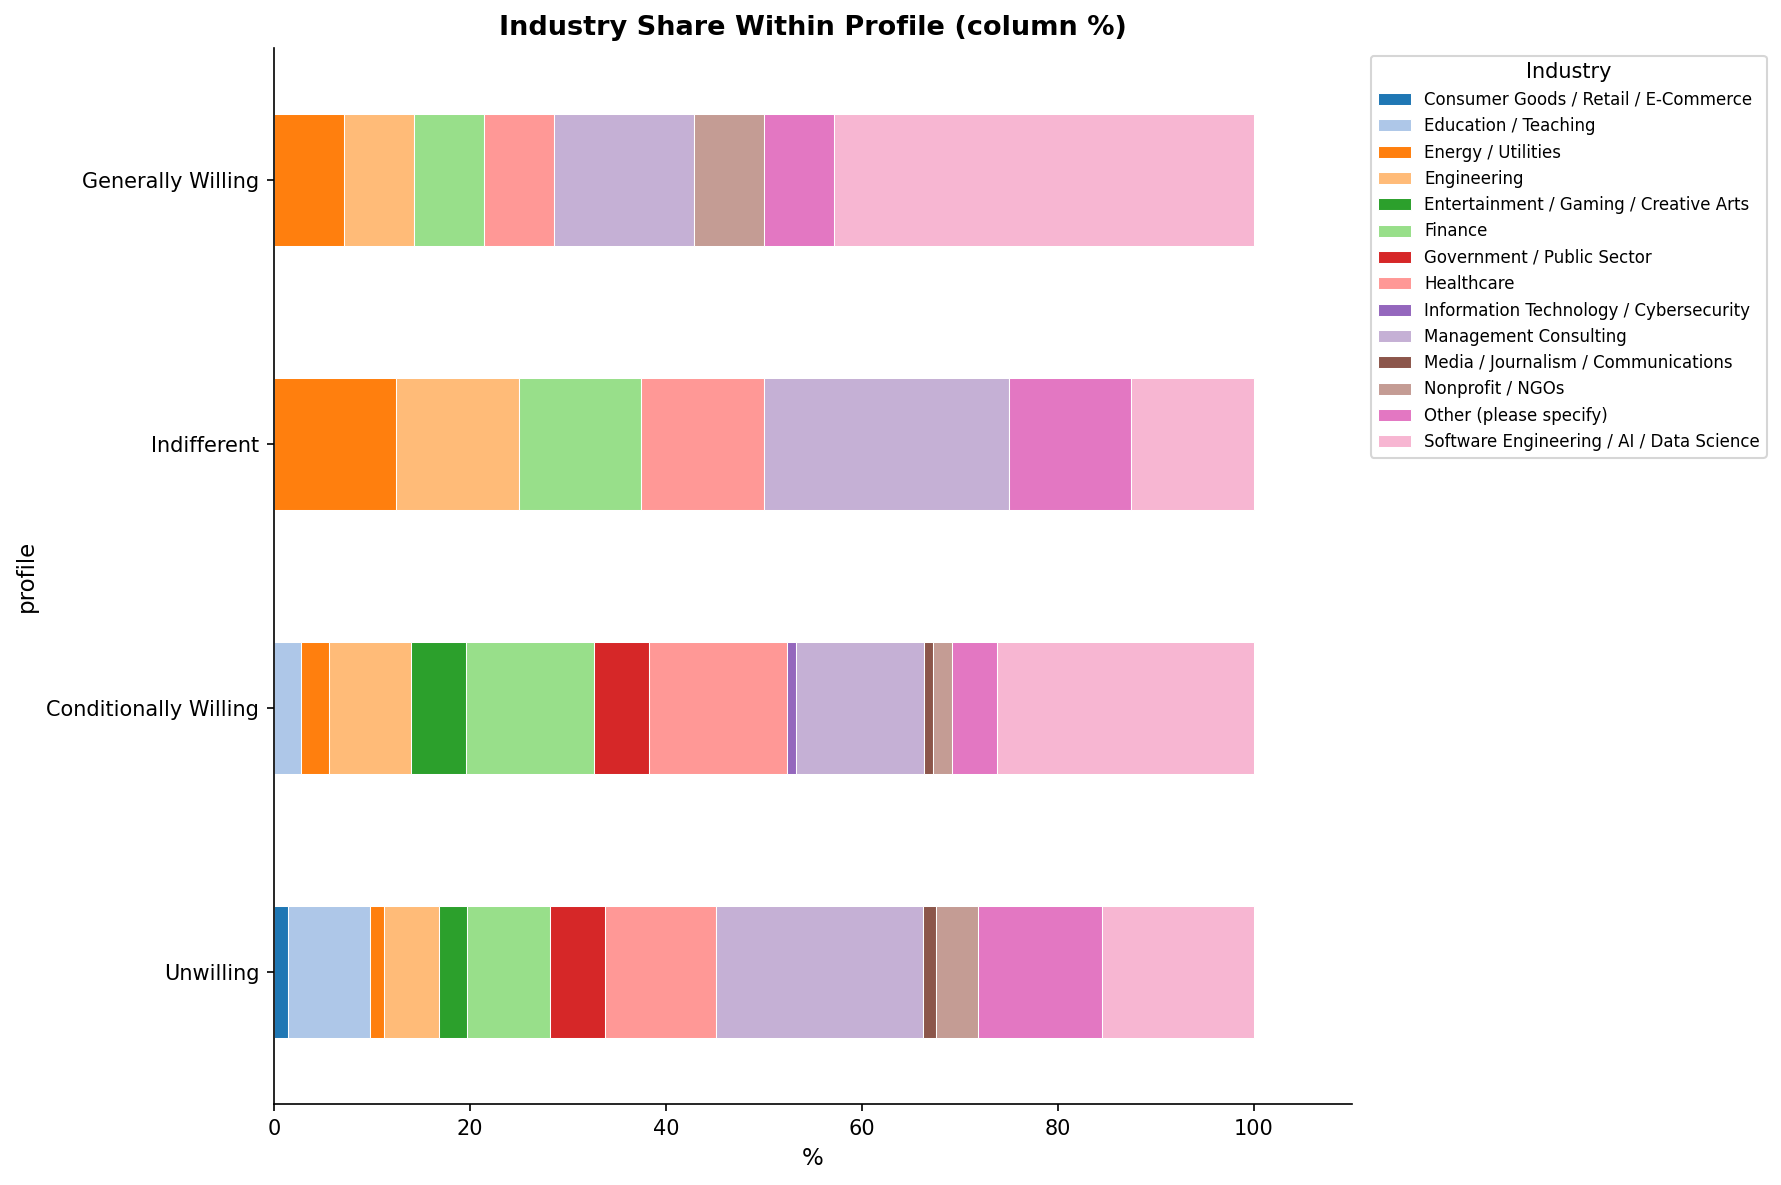

In [43]:
df_p = df.dropna(subset=['profile','industry_simple'])
df_p = df_p[df_p['profile'] != 'Mixed']

if len(df_p) > 0:
    ct_row = pd.crosstab(df_p['industry_simple'], df_p['profile'], normalize='index') * 100
    ct_row = ct_row.reindex(columns=[p for p in profile_order if p in ct_row.columns])

    fig, ax = plt.subplots(figsize=(12, 8))
    ct_row.plot(kind='barh', stacked=True, ax=ax,
                color=[profile_colors[p] for p in ct_row.columns],
                edgecolor='white', linewidth=0.5)
    ax.set_xlabel('%')
    ax.set_xlim(0, 110)
    ax.set_title('Profile Mix Within Industry (row %)', fontweight='bold')
    ax.legend(title='Profile', fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('fig_h4_profile_mix_within_industry_horizontal.png', bbox_inches='tight', dpi=150)
    plt.show()

    ct_col = pd.crosstab(df_p['industry_simple'], df_p['profile'], normalize='columns') * 100
    ct_col = ct_col.reindex(columns=[p for p in profile_order if p in ct_col.columns]).T
    industry_colors = sns.color_palette('tab20', n_colors=len(ct_col.columns))

    fig, ax = plt.subplots(figsize=(12, 8))
    ct_col.plot(kind='barh', stacked=True, ax=ax,
                color=industry_colors,
                edgecolor='white', linewidth=0.5)
    ax.set_xlabel('%')
    ax.set_xlim(0, 110)
    ax.set_title('Industry Share Within Profile (column %)', fontweight='bold')
    ax.legend(title='Industry', fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('fig_h4_industry_share_within_profile_horizontal.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    for title in ['Profile Mix Within Industry (row %)', 'Industry Share Within Profile (column %)']:
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.text(0.5, 0.5, 'Awaiting data', ha='center', va='center',
                transform=ax.transAxes, fontsize=13, color=NEUTRAL_COLOR)
        ax.set_axis_off()
        ax.set_title(title, fontweight='bold')
        plt.tight_layout()
        plt.show()

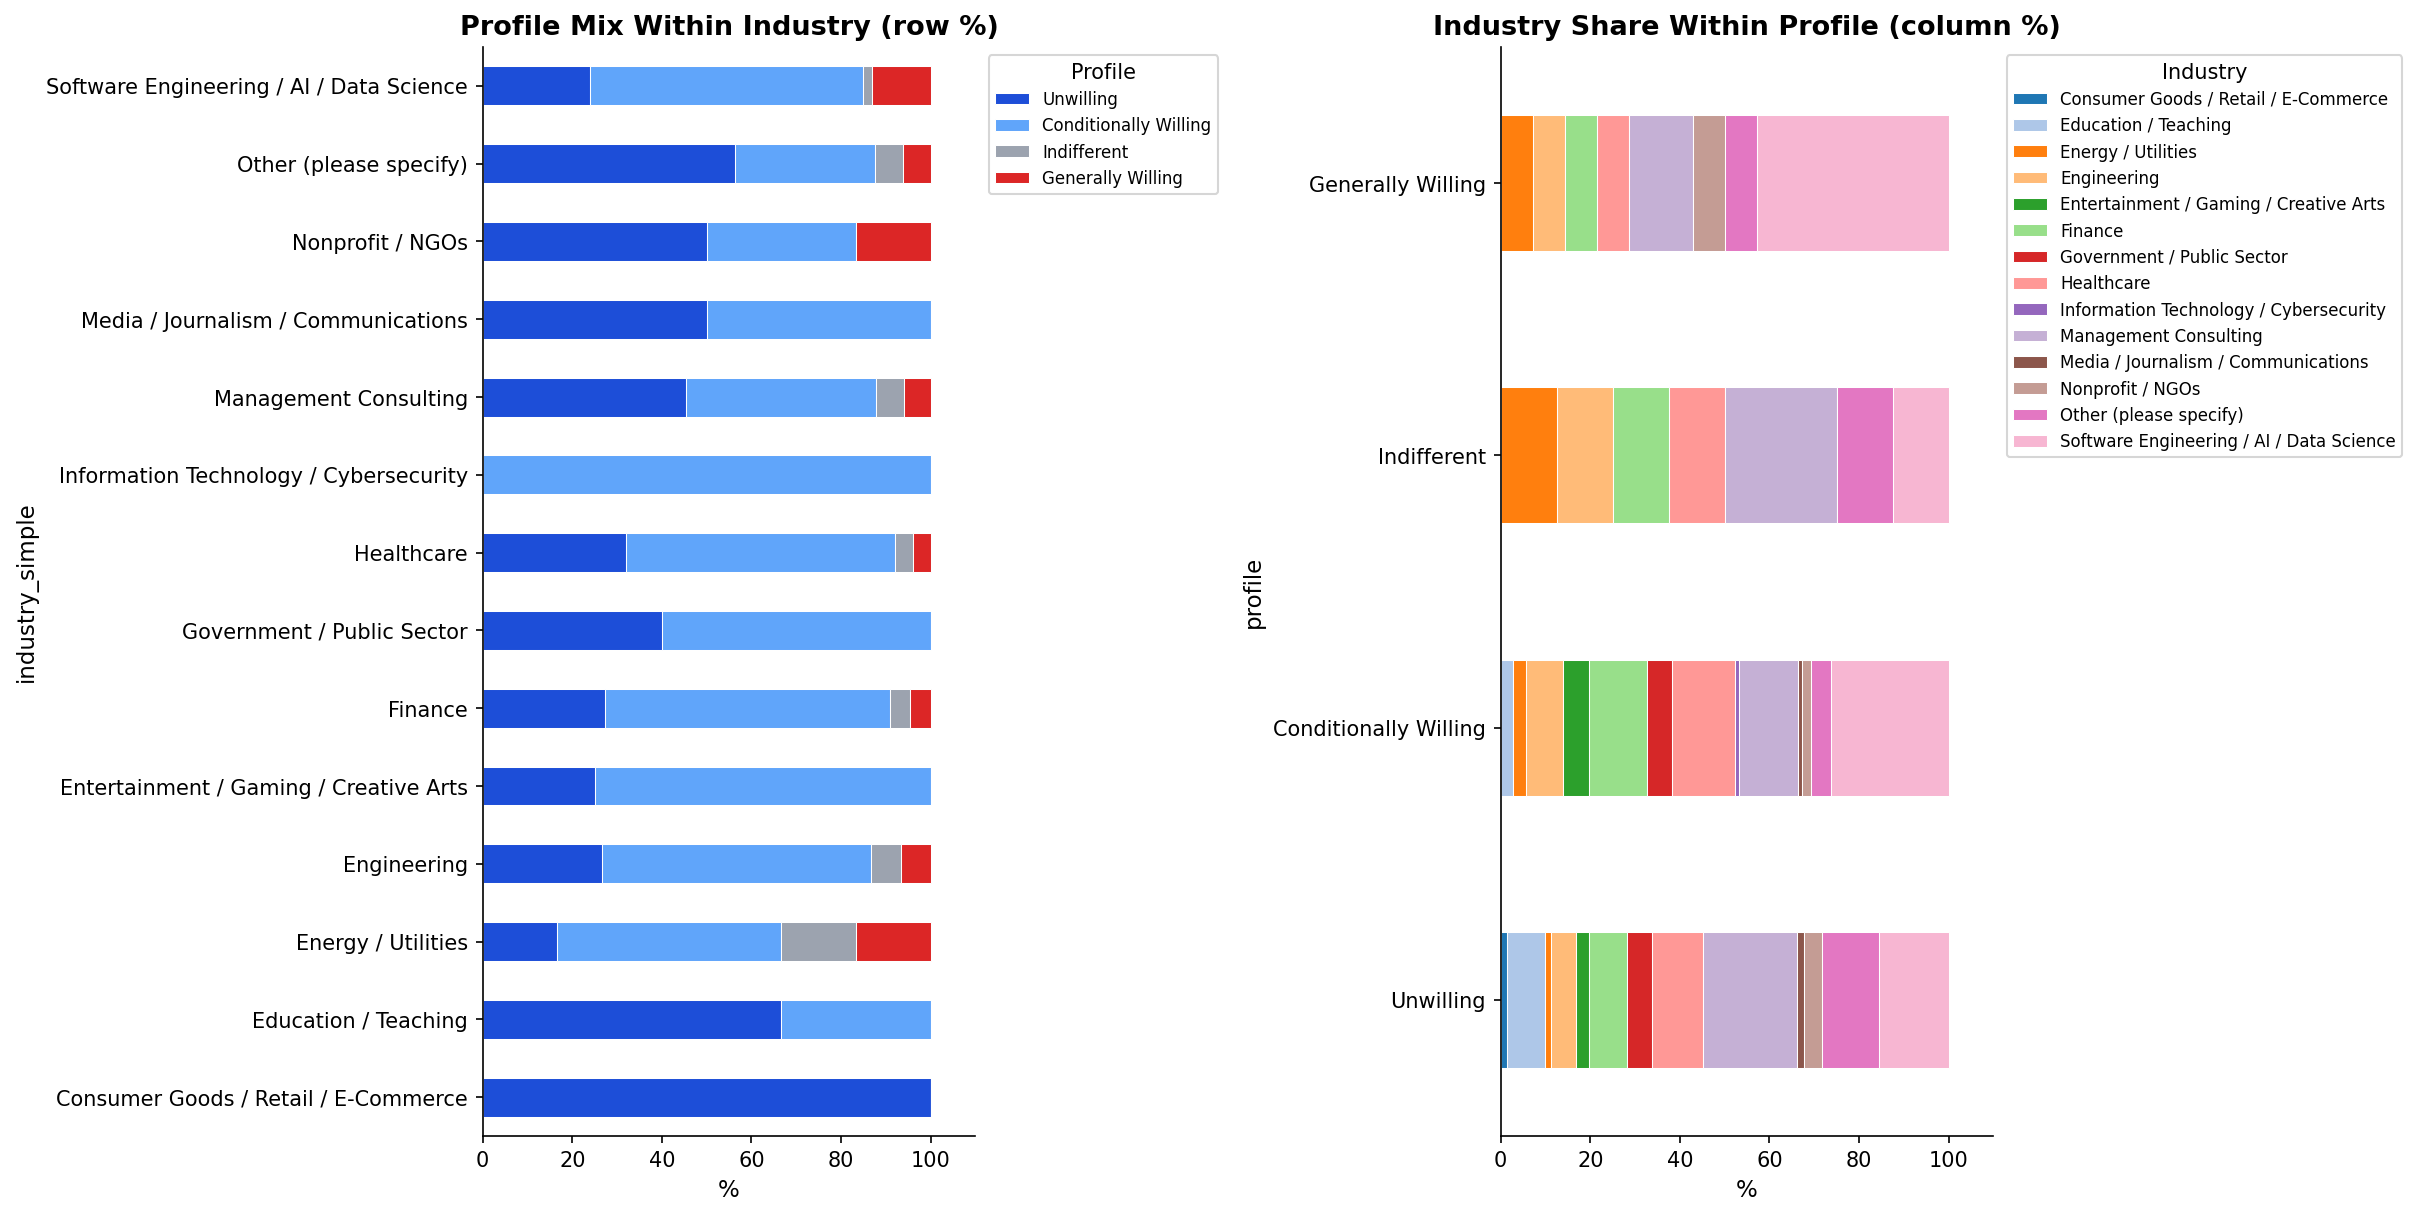

In [44]:
df_p = df.dropna(subset=['profile','industry_simple'])
df_p = df_p[df_p['profile'] != 'Mixed']

if len(df_p) > 0:
    ct_row = pd.crosstab(df_p['industry_simple'], df_p['profile'], normalize='index') * 100
    ct_row = ct_row.reindex(columns=[p for p in profile_order if p in ct_row.columns])

    ct_col = pd.crosstab(df_p['industry_simple'], df_p['profile'], normalize='columns') * 100
    ct_col = ct_col.reindex(columns=[p for p in profile_order if p in ct_col.columns]).T
    industry_colors = sns.color_palette('tab20', n_colors=len(ct_col.columns))

    fig, axes = plt.subplots(1, 2, figsize=(16, 8), constrained_layout=True)

    ax = axes[0]
    ct_row.plot(kind='barh', stacked=True, ax=ax,
                color=[profile_colors[p] for p in ct_row.columns],
                edgecolor='white', linewidth=0.5)
    ax.set_xlabel('%')
    ax.set_xlim(0, 110)
    ax.set_title('Profile Mix Within Industry (row %)', fontweight='bold')
    ax.legend(title='Profile', fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

    ax2 = axes[1]
    ct_col.plot(kind='barh', stacked=True, ax=ax2,
                color=industry_colors,
                edgecolor='white', linewidth=0.5)
    ax2.set_xlabel('%')
    ax2.set_xlim(0, 110)
    ax2.set_title('Industry Share Within Profile (column %)', fontweight='bold')
    ax2.legend(title='Industry', fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.savefig('fig_h4_profile_mix_within_industry_side_by_side.png', bbox_inches='tight', dpi=150)
    plt.show()
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
    for ax, title in zip(axes, ['Profile Mix Within Industry (row %)', 'Industry Share Within Profile (column %)']):
        ax.text(0.5, 0.5, 'Awaiting data', ha='center', va='center',
                transform=ax.transAxes, fontsize=13, color=NEUTRAL_COLOR)
        ax.set_axis_off()
        ax.set_title(title, fontweight='bold')
    plt.show()


---
## 9. Academic Level × Profile

> *"Academic level showed little predictive power, with undergraduate and graduate respondents distributed roughly proportionally across all groups, suggesting the normalization effect is better explained by field-specific competitive culture than by years of academic training."*

In [51]:
# ── Cross-tab: profile × academic year ────────────────────────────────────────
year_order = ['Freshman','Sophomore','Junior','Senior','New Grad (0-1 YOE)',
              'Masters Student','MBA Student','PhD Student','Early Career (1-3 YOE)',
              'Mid Career (3+ YOE)']

df_year = df.dropna(subset=['profile','q15_year'])
df_year = df_year[df_year['profile'] != 'Mixed']

if len(df_year) > 0:
    ct_year = pd.crosstab(df_year['q15_year'], df_year['profile'],
                          normalize='index') * 100
    ct_year = ct_year.reindex(columns=[p for p in profile_order if p in ct_year.columns])
    print('── Profile Mix Within Academic Level (row %) ──')
    print(ct_year.round(1).to_string())

    # Chi-square test of independence
    ct_year_counts = pd.crosstab(df_year['q15_year'], df_year['profile'])
    if ct_year_counts.shape[0] >= 2 and ct_year_counts.shape[1] >= 2:
        chi2, p_chi2, dof, _ = stats.chi2_contingency(ct_year_counts)
        print(f'\nChi-square (year × profile): χ²={chi2:.3f}, df={dof}, p={p_chi2:.3f}')
        print('  (p > 0.05 supports "little predictive power" claim)')
    else:
        print('\nChi-square: insufficient variation — will compute with full sample.')
else:
    print('No data yet.')

── Profile Mix Within Academic Level (row %) ──
profile             Unwilling  Conditionally Willing  Indifferent  Generally Willing
q15_year                                                                            
Experienced Grad         33.3                   66.7          0.0                0.0
Freshman                 25.0                   60.0          5.0               10.0
Graduate Student         45.8                   41.7          4.2                8.3
Junior                   42.2                   46.9          1.6                9.4
New Grad (0-1 YOE)       16.7                   66.7          0.0               16.7
Other                    33.3                   66.7          0.0                0.0
Senior                   27.7                   57.4          8.5                6.4
Sophomore                36.4                   60.6          3.0                0.0

Chi-square (year × profile): χ²=14.067, df=21, p=0.867
  (p > 0.05 supports "little predictive power"

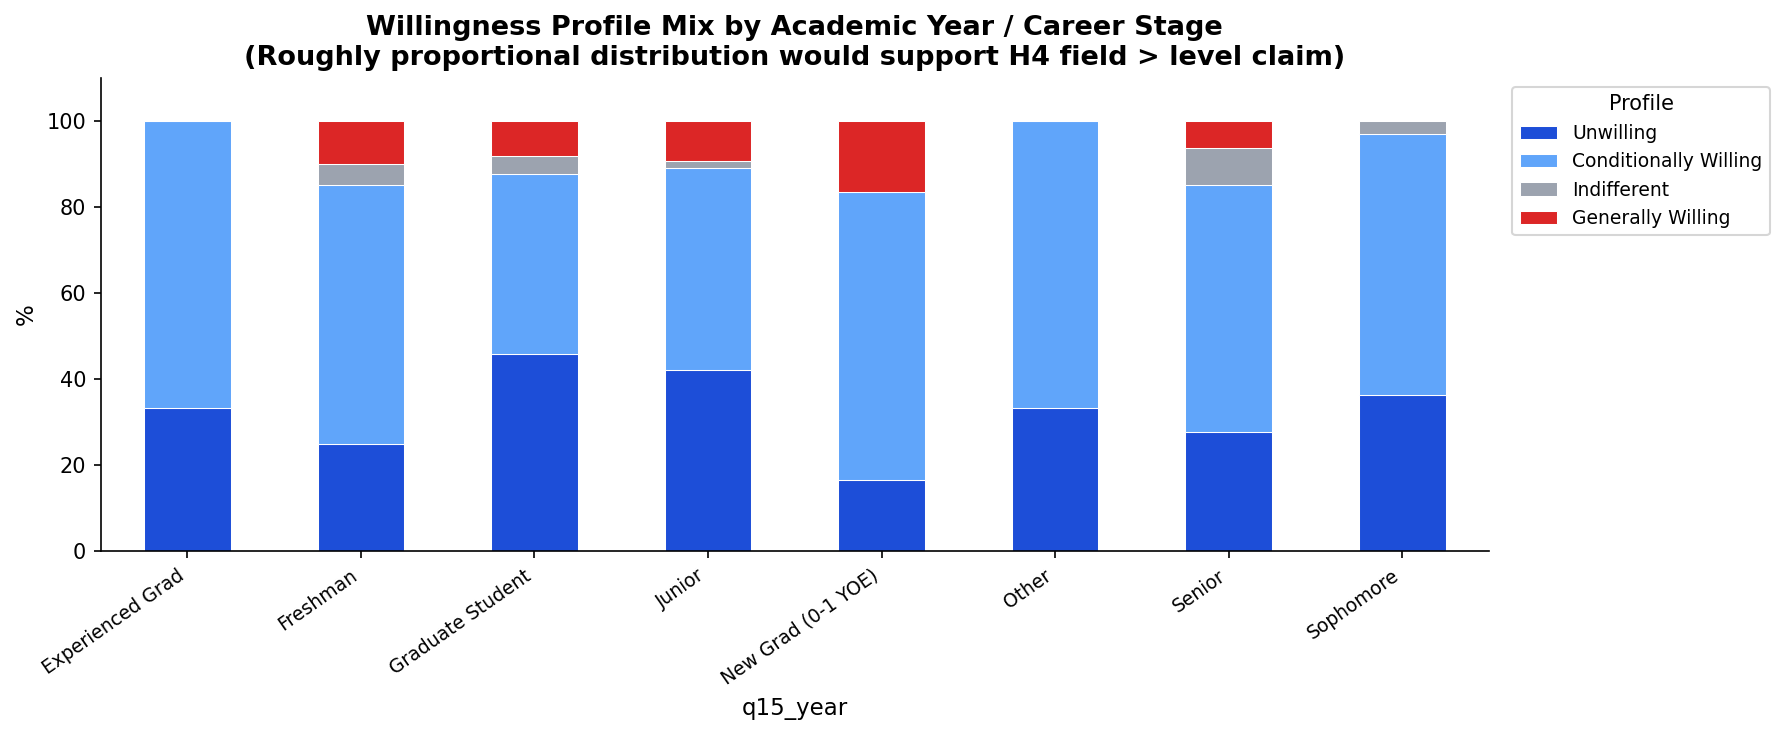

Saved: fig_h4_profile_by_year.png


In [52]:
# ── Figure 7: Academic year × profile stacked bar ─────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
df_y2 = df.dropna(subset=['profile','q15_year'])
df_y2 = df_y2[df_y2['profile'] != 'Mixed']
if len(df_y2) > 0:
    ct = pd.crosstab(df_y2['q15_year'], df_y2['profile'],
                     normalize='index') * 100
    ct = ct.reindex(columns=[p for p in profile_order if p in ct.columns])
    ct.plot(kind='bar', stacked=True, ax=ax,
            color=[profile_colors[p] for p in ct.columns],
            edgecolor='white', linewidth=0.5)
    ax.set_ylabel('%')
    ax.set_ylim(0, 110)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right', fontsize=9)
    ax.legend(title='Profile', fontsize=9, bbox_to_anchor=(1.01, 1), loc='upper left')
else:
    ax.text(0.5, 0.5, 'Awaiting data', ha='center', va='center',
            transform=ax.transAxes, fontsize=13, color=NEUTRAL_COLOR)
ax.set_title('Willingness Profile Mix by Academic Year / Career Stage\n'
             '(Roughly proportional distribution would support H4 field > level claim)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h4_profile_by_year.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h4_profile_by_year.png')

---
## 10. Generally Willing Group Deep-Dive

> *"The Generally Willing group... also showed the lowest confidence scores on Questions 23 and 24, suggesting their willingness is partially driven by a belief that consequences are unlikely rather than by indifference to the ethics of cheating as such."*

In [60]:
df_p = df.dropna(subset=['profile','industry_simple'])

# ── Generally Willing profile characteristics ──────────────────────────────────
df_gw = df[df['profile'] == 'Generally Willing'].copy()
df_cw = df[df['profile'] == 'Conditionally Willing'].copy()
df_uw = df[df['profile'] == 'Unwilling'].copy()
df_mx = df[df['profile'] == 'Mixed'].copy()
df_ind = df[df['profile'] == 'Indifferent'].copy()
print('── Profile Sizes ──')

print(f'Profile sizes: GW={len(df_gw)}, CW={len(df_cw)}, UW={len(df_uw)}, MX={len(df_mx)}, IND={len(df_ind)}')

compare_cols = {
    'q23_detect_n'  : 'Detection confidence (Q23)',
    'q24_enforce_n' : 'Enforcement confidence (Q24)',
    'q2_pct_n'      : 'Peer cheating estimate % (Q2)',
    'q3_mean_accept': 'Mean acceptability (Q3)',
}

print('\n── Key Characteristics by Profile ──')
print(f'  {"Measure":<40} {"GW":>8} {"CW":>8} {"UW":>8}')
print('  ' + '-'*68)
for col, lbl in compare_cols.items():
    gw_m = df_gw[col].mean()
    cw_m = df_cw[col].mean()
    uw_m = df_uw[col].mean()
    fmt  = lambda v: f'{v:.2f}' if not np.isnan(v) else 'n/a'
    print(f'  {lbl:<40} {fmt(gw_m):>8} {fmt(cw_m):>8} {fmt(uw_m):>8}')

# Industry breakdown for GW
print('\n── Generally Willing: Industry Breakdown ──')
print(df_gw['industry_simple'].value_counts().to_string() if len(df_gw) > 0 else '  [no data]')

print('\n── Conditionally Willing: Industry Breakdown ──')
print(df_cw['industry_simple'].value_counts().to_string() if len(df_cw) > 0 else '  [no data]')

── Profile Sizes ──
Profile sizes: GW=14, CW=107, UW=71, MX=49, IND=8

── Key Characteristics by Profile ──
  Measure                                        GW       CW       UW
  --------------------------------------------------------------------
  Detection confidence (Q23)                   1.62     1.77     1.67
  Enforcement confidence (Q24)                 2.38     2.26     2.07
  Peer cheating estimate % (Q2)               59.21    37.25    29.44
  Mean acceptability (Q3)                      3.57     3.04     2.61

── Generally Willing: Industry Breakdown ──
industry_simple
Software Engineering / AI / Data Science    6
Management Consulting                       2
Engineering                                 1
Finance                                     1
Healthcare                                  1
Other (please specify)                      1
Energy / Utilities                          1
Nonprofit / NGOs                            1

── Conditionally Willing: Industry Breakd

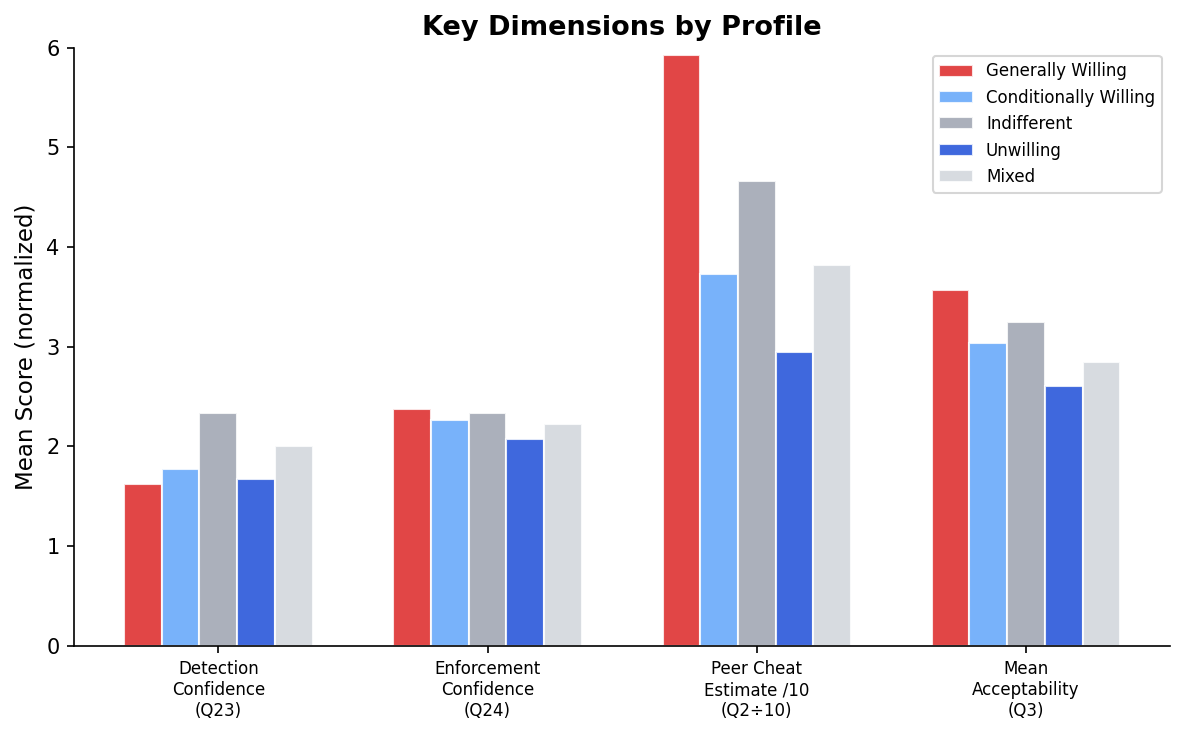

Saved: fig_h4_profile_key_dimensions.png


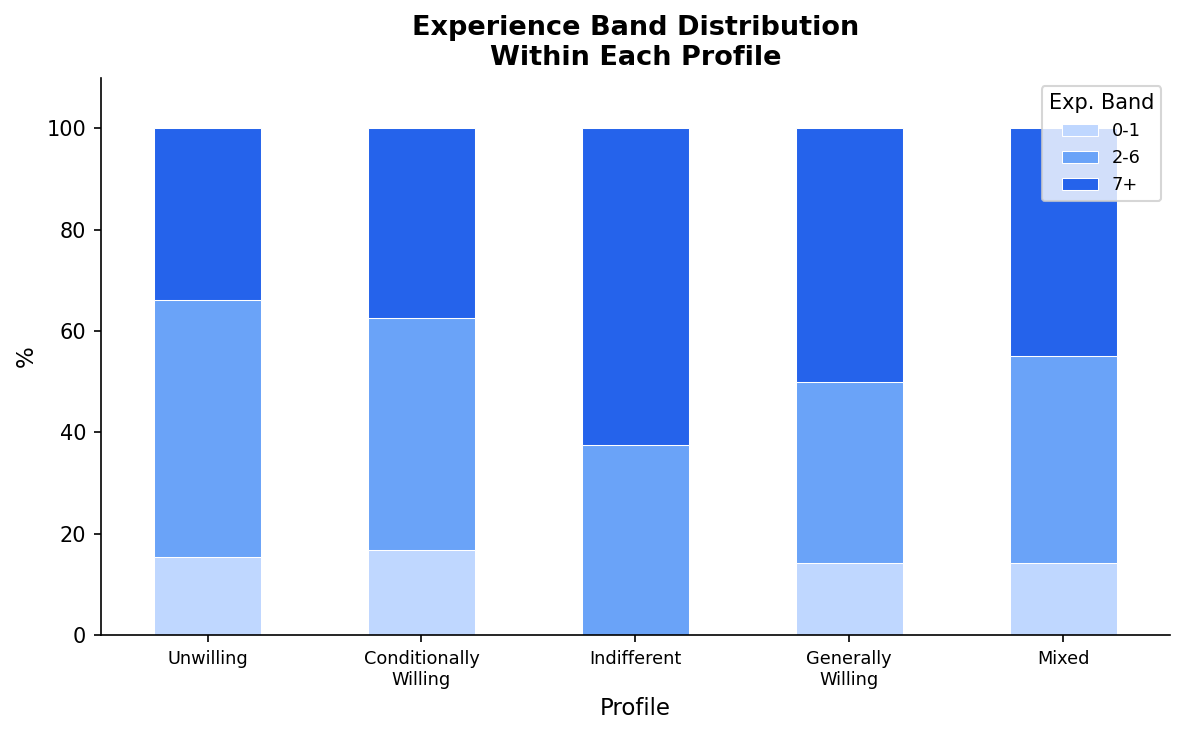

Saved: fig_h4_profile_experience_by_profile.png


In [79]:
df_p = df.dropna(subset=['profile','industry_simple'])
# ── Figure 8a: Profile comparison on key dimensions ─────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

metrics     = ['Detection\nConfidence\n(Q23)', 'Enforcement\nConfidence\n(Q24)',
               'Peer Cheat\nEstimate /10\n(Q2÷10)', 'Mean\nAcceptability\n(Q3)']
metric_cols = ['q23_detect_n', 'q24_enforce_n', 'q2_pct_n', 'q3_mean_accept']
divisors    = [1, 1, 10, 1]

pal = sns.color_palette("coolwarm", n_colors=5)
profiles_to_plot = [
    ('Generally Willing', df_gw, profile_colors['Generally Willing']),
    ('Conditionally Willing', df_cw, profile_colors['Conditionally Willing']),
    ('Indifferent', df_ind, profile_colors['Indifferent']),
    ('Unwilling', df_uw, profile_colors['Unwilling']),
    ('Mixed', df_mx, profile_colors['Mixed']),
]
x = np.arange(len(metrics))
width = 0.14
n_profiles = len(profiles_to_plot)
offsets = np.linspace(-width*(n_profiles-1)/2, width*(n_profiles-1)/2, n_profiles)

for (label, df_grp, color), offset in zip(profiles_to_plot, offsets):
    vals = [df_grp[col].mean() / div for col, div in zip(metric_cols, divisors)]
    ax.bar(x + offset, vals, width, label=label, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=8)
ax.set_ylabel('Mean Score (normalized)')
ax.set_title('Key Dimensions by Profile', fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylim(0, 6)
plt.tight_layout()
plt.savefig('fig_h4_profile_key_dimensions.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h4_profile_key_dimensions.png')


# ── Figure 8b: Experience band distribution within each profile ────────────
fig, ax = plt.subplots(figsize=(8, 5))
df_exp_prof = df.dropna(subset=['profile', 'exp_band'])
if len(df_exp_prof) > 0:
    ct_exp = pd.crosstab(df_exp_prof['profile'], df_exp_prof['exp_band'],
                         normalize='index') * 100
    ct_exp = ct_exp.reindex(index=[p for p in profile_order if p in ct_exp.index],
                             columns=[b for b in band_order if b in ct_exp.columns])
    ct_exp.plot(kind='bar', stacked=True, ax=ax,
                color=BAND_COLORS[:len(ct_exp.columns)],
                edgecolor='white', linewidth=0.5)
    ax.set_ylabel('%')
    ax.set_ylim(0, 110)
    ax.set_xticklabels([p.replace(' ', '\n') for p in ct_exp.index], rotation=0, fontsize=8.5)
    ax.set_xlabel('Profile')
    ax.legend(title='Exp. Band', fontsize=8.5)
else:
    ax.text(0.5, 0.5, 'Awaiting data', ha='center', va='center',
            transform=ax.transAxes, fontsize=13, color=NEUTRAL_COLOR)
    ax.set_axis_off()

ax.set_title('Experience Band Distribution\nWithin Each Profile', fontweight='bold')
plt.tight_layout()
plt.savefig('fig_h4_profile_experience_by_profile.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig_h4_profile_experience_by_profile.png')

---
## 11. Summary: All [X] Fill-In Values for LaTeX

In [24]:
print('=' * 68)
print('H4 FILL-IN REFERENCE SHEET')
print('=' * 68)

def fmt(v, suffix='', dec=1):
    return f'{v:.{dec}f}{suffix}' if not (isinstance(v, float) and np.isnan(v)) else '[no data]'

# ── Experience band distribution ──────────────────────────────────────────────
print('\n── Experience Band Distribution ──')
for b in band_order:
    print(f'  {b}: n={band_counts[b]} ({band_pct[b]:.1f}%)')
print(f'  [X, X, X, X] = [{", ".join(str(band_counts[b]) for b in band_order)}]')

# ── Q2 peer estimate by band ──────────────────────────────────────────────────
print('\n── Q2 Peer Cheating Estimate by Band ──')
for b in ['0–1', '2–6']:
    v = peer_by_band.loc[b, 'mean'] if b in peer_by_band.index else np.nan
    print(f'  {b} band: {fmt(v, "%")}')
# 7+ combined
idx_7p = [b for b in ['7–10','11+'] if b in peer_by_band.index and not np.isnan(peer_by_band.loc[b,'mean'])]
v7p_vals = [peer_by_band.loc[b,'mean'] for b in idx_7p]
v7p_mean = np.mean(v7p_vals) if v7p_vals else np.nan
print(f'  7+ band (combined): {fmt(v7p_mean, "%")}')

# ── Q13a willingness ratios ───────────────────────────────────────────────────
print('\n── Q13a Willingness Ratios (vs 0–1 band) ──')
base = will_by_band.loc['0–1','pct_willing'] if '0–1' in will_by_band.index else np.nan
for b in ['2–6', '7–10', '11+']:
    r = will_by_band.loc[b,'pct_willing'] if b in will_by_band.index else np.nan
    ratio = r/base if not np.isnan(base) and not np.isnan(r) and base > 0 else np.nan
    print(f'  {b} band: {fmt(ratio, "x", dec=2)} more likely (base={fmt(base,"%")}, {b}={fmt(r,"%")})')

# ── Q3 acceptability gradient ─────────────────────────────────────────────────
print('\n── Q3 Acceptability: Largest Experience Gradient ──')
if '11+' in accept_band_df.columns and '0–1' in accept_band_df.columns:
    diffs2 = (accept_band_df['11+'] - accept_band_df['0–1']).dropna().sort_values(ascending=False)
    for lbl2, d in diffs2.head(3).items():
        print(f'  {lbl2}: Δ={d:.2f}')
else:
    print('  [no data yet]')

# ── Profile distribution ──────────────────────────────────────────────────────
print('\n── Willingness Profiles ──')
for p in [p for p in profile_order if p != 'Mixed']:
    print(f'  {p:<22}: n={profile_counts[p]} ({profile_pct[p]:.1f}%)')

print('\n' + '=' * 68)
print('NOTE: [no data] values will populate once the full sample is collected.')
print('      Re-run all cells top-to-bottom after each data update.')

H4 FILL-IN REFERENCE SHEET

── Experience Band Distribution ──
  0-1: n=38 (15.3%)
  2-6: n=113 (45.4%)
  7+: n=98 (39.4%)
  [X, X, X, X] = [38, 113, 98]

── Q2 Peer Cheating Estimate by Band ──
  0–1 band: [no data]
  2–6 band: [no data]
  7+ band (combined): [no data]

── Q13a Willingness Ratios (vs 0–1 band) ──
  2–6 band: [no data] more likely (base=[no data], 2–6=[no data])
  7–10 band: [no data] more likely (base=[no data], 7–10=[no data])
  11+ band: [no data] more likely (base=[no data], 11+=[no data])

── Q3 Acceptability: Largest Experience Gradient ──
  [no data yet]

── Willingness Profiles ──
  Unwilling             : n=71 (28.5%)
  Conditionally Willing : n=107 (43.0%)
  Indifferent           : n=8 (3.2%)
  Generally Willing     : n=14 (5.6%)
  Contrarian            : n=0 (0.0%)

NOTE: [no data] values will populate once the full sample is collected.
      Re-run all cells top-to-bottom after each data update.
